# Agrupamiento espectral
## Star Wars II: Attack of the Clones

La película se modela como una red de coapariciones: si dos personajes comparten escena, existe una arista entre ellos. Cuando la arista tiene peso, ese peso representa cuántas veces se repite esa coaparición.

En *Attack of the Clones* esto es importante porque la historia no avanza como una sola conversación continua. Se divide en frentes narrativos: la investigación de OBI-WAN hacia Kamino y Geonosis, el arco ANAKIN-PADMÉ en Naboo/Tatooine, y la trama político-militar del Senado, los Jedi y los separatistas. Una red de coapariciones permite ver si esos frentes aparecen también como estructura matemática.

Como la red es conexa, puedo empezar con toda la red y bisecarla usando el vector de Fiedler. Después reviso las subredes resultantes; si alguna todavía tiene conectividad algebraica baja, la vuelvo a dividir. La lectura no es solo “encontrar grupos”, sino preguntar qué cortes separan subtramas, qué personajes funcionan como puentes y qué tan compactos son los bloques que aparecen.

In [1]:
import xml.etree.ElementTree as ET
from pathlib import Path

import matplotlib.pyplot as plt
from matplotlib.colors import Normalize
import networkx as nx
import numpy as np
import pandas as pd
from IPython.display import display
from networkx.algorithms.community import greedy_modularity_communities

SEED = 863

plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False
pd.options.display.max_colwidth = 200

In [2]:
def get_display_labels(G):
    raw = nx.get_node_attributes(G, "label")
    return {node: raw.get(node, str(node)) for node in G.nodes()}


def rounded_list(values, digits=6):
    return [round(float(x), digits) for x in np.asarray(values, dtype=float)]


def communities_to_lookup(communities):
    lookup = {}
    for idx, community in enumerate(communities):
        for node in community:
            lookup[node] = idx
    return lookup


def algebraic_connectivity_safe(G, weight=None):
    if G.number_of_nodes() < 2 or not nx.is_connected(G):
        return 0.0
    return float(nx.algebraic_connectivity(G, weight=weight))


def spectral_report(G, labels, title, weight=None):
    print("=" * 100)
    print(title)
    print(f"nodos = {G.number_of_nodes()}, aristas = {G.number_of_edges()}, conexa = {nx.is_connected(G)}")
    spectrum = rounded_list(nx.laplacian_spectrum(G, weight=weight))
    print("laplacian_spectrum =", spectrum)
    result = {
        "title": title,
        "spectrum": spectrum,
        "groups": [set(G.nodes())],
        "lambda2": 0.0,
    }
    if not nx.is_connected(G):
        component_sizes = sorted([len(c) for c in nx.connected_components(G)], reverse=True)
        print("La subred no es conexa; antes de bisectar hay que separar componentes.")
        print("tamano_componentes =", component_sizes)
        return result
    lambda2 = algebraic_connectivity_safe(G, weight=weight)
    fiedler = nx.fiedler_vector(G, weight=weight)
    ordering = list(nx.spectral_ordering(G, weight=weight))
    groups = [set(part) for part in nx.spectral_bisection(G, weight=weight)]
    print(f"lambda_2 = {lambda2:.6f}")
    print("spectral_ordering =", [labels[node] for node in ordering])
    print("grupo_1 =", sorted(labels[node] for node in groups[0]))
    print("grupo_2 =", sorted(labels[node] for node in groups[1]))
    fiedler_df = (
        pd.DataFrame(
            {
                "nodo": [labels[node] for node in G.nodes()],
                "componente_fiedler": fiedler,
                "signo": np.where(fiedler >= 0, "+", "-"),
            }
        )
        .sort_values("componente_fiedler")
        .reset_index(drop=True)
    )
    display(fiedler_df.round(4))
    result.update(
        {
            "lambda2": lambda2,
            "ordering": ordering,
            "groups": groups,
            "fiedler_df": fiedler_df,
        }
    )
    return result


def partition_summary(G, communities, labels, weight=None):
    rows = []
    for idx, community in enumerate(sorted([set(c) for c in communities], key=len, reverse=True), start=1):
        SG = G.subgraph(community).copy()
        rows.append(
            {
                "grupo": idx,
                "nodos": len(community),
                "aristas_internas": SG.number_of_edges(),
                "densidad": round(nx.density(SG), 4) if len(community) > 1 else 0.0,
                "lambda_2": round(algebraic_connectivity_safe(SG, weight=weight), 4),
                "miembros": ", ".join(sorted(labels[node] for node in community)),
            }
        )
    return pd.DataFrame(rows)


def draw_partition(ax, G, communities, labels, title, pos=None):
    groups = [set(c) for c in communities]
    if pos is None:
        pos = nx.kamada_kawai_layout(G)
    lookup = communities_to_lookup(groups)
    node_colors = [lookup[node] for node in G.nodes()]
    node_sizes = [220 + 20 * G.degree(node) for node in G.nodes()]
    nx.draw_networkx_edges(G, pos, ax=ax, alpha=0.25, width=1.0, edge_color="#94a3b8")
    nx.draw_networkx_nodes(
        G,
        pos,
        ax=ax,
        node_color=node_colors,
        node_size=node_sizes,
        cmap="nipy_spectral",
        linewidths=0.8,
        edgecolors="white",
    )
    font_size = 9 if G.number_of_nodes() <= 25 else 7
    nx.draw_networkx_labels(G, pos, ax=ax, labels=labels, font_size=font_size)
    ax.set_title(title)
    ax.axis("off")
    return pos


def plot_partition_sequence(G, labels, states, pos=None, ncols=2, figsize=(18, 12)):
    if pos is None:
        pos = nx.kamada_kawai_layout(G)
    nrows = int(np.ceil(len(states) / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=figsize)
    axes = np.atleast_1d(axes).ravel()
    for ax, state in zip(axes, states):
        draw_partition(ax, G, state["groups"], labels, state["title"], pos=pos)
    for ax in axes[len(states):]:
        ax.axis("off")
    plt.tight_layout()
    plt.show()


def comparison_table(entries):
    return pd.DataFrame(entries).sort_values(["grafo", "Q"], ascending=[True, False]).reset_index(drop=True)

# nx.read_gexf falla con este archivo dinámico en NetworkX 3.6, así que hago un parser manual.
def read_dynamic_gexf_as_graph(fp):
    ns = {"g": "http://www.gexf.net/1.2draft"}
    root = ET.parse(fp).getroot()
    G = nx.Graph()
    for node in root.findall('.//g:node', ns):
        node_id = int(node.attrib["id"])
        G.add_node(node_id, label=node.attrib.get("label", str(node_id)))
    for edge in root.findall('.//g:edge', ns):
        u = int(edge.attrib["source"])
        v = int(edge.attrib["target"])
        weight = 1.0
        for attvalue in edge.findall('.//g:attvalue', ns):
            if attvalue.attrib.get("for") == "weight":
                weight = float(attvalue.attrib.get("value", 1.0))
        if G.has_edge(u, v):
            G[u][v]["weight"] += weight
        else:
            G.add_edge(u, v, weight=weight)
    return G

def find_project_root(start=None):
    start = Path.cwd().resolve() if start is None else Path(start).resolve()
    for candidate in [start, *start.parents]:
        if (candidate / "data").exists() and (candidate / "notebooks").exists():
            return candidate
    return start

PROJECT_ROOT = find_project_root()
folder = PROJECT_ROOT / "data/dataverse/gexf"
movie_id = 774
fp = folder / f"{movie_id}.gexf"

G_sw = read_dynamic_gexf_as_graph(fp)
labels_sw = get_display_labels(G_sw)
pos_sw = nx.kamada_kawai_layout(G_sw)

resumen_sw = pd.DataFrame(
    [
        {
            "nodos": G_sw.number_of_nodes(),
            "aristas": G_sw.number_of_edges(),
            "densidad": round(nx.density(G_sw), 4),
            "grado_medio": round(np.mean([grado for _, grado in G_sw.degree()]), 4),
            "es_conexa": nx.is_connected(G_sw),
        }
    ]
)

display(resumen_sw)

,nodos,aristas,densidad,grado_medio,es_conexa
0,47,148,0.1369,6.2979,True


## 1. Primera particion

In [3]:
root_sw = spectral_report(G_sw, labels_sw, "Paso 1. Red completa de coapariciones", weight="weight")

Paso 1. Red completa de coapariciones
nodos = 47, aristas = 148, conexa = True
laplacian_spectrum = [0.0, 0.911418, 0.944666, 1.0, 1.0, 1.0, 1.063891, 1.531029, 1.841322, 1.958629, 2.0, 2.0, 2.020357, 2.178905, 2.30489, 2.748596, 3.0, 3.0, 3.093237, 3.557152, 3.702999, 4.0, 4.01698, 4.49423, 4.707297, 5.263098, 5.981054, 6.253796, 6.714378, 7.608731, 8.0, 8.205481, 8.693087, 8.832263, 9.894871, 10.339655, 11.0, 11.214526, 12.24788, 13.447782, 16.862082, 19.251971, 21.705113, 32.940109, 38.887711, 63.756535, 78.824279]


lambda_2 = 0.911418
spectral_ordering = ['PK-4', 'HERMIONE BAGWA', 'DEXTER JETTSTER', 'JOCASTA NU', 'JANGO', 'BOBA FETT', 'TAUN WE', 'JANGO FETT', 'LAMA SU', 'DOOKU', 'SHMI', 'WATTO', 'ZAM WESSEL', 'ELAN', 'OBI-WAN', 'CHILDREN', 'DORME', 'WINDU', 'MACE', 'CAPTAIN TYPHO', 'JAR JAR', 'ANAKIN', 'MAS AMEDDA', 'SENATOR ASK AAK', 'BAIL ORGANA', 'AMIDALA', 'ORN FREE TAA', 'PALPATINE', 'RUWEE', 'QUEEN JAMILLIA', 'SIO BIBBLE', 'RYOO & POOJA', 'JOBAL', 'SOLA', 'CLIEGG', 'OWEN', 'BERU', 'KI-ADI-MUNDI', 'YODA', 'PADMÉ', 'THREEPIO', 'MACE WINDU', 'POGGLE', 'SUN RIT', 'NUTE GUNRAY', 'COUNT DOOKU', 'DARTH SIDIOUS']
grupo_1 = ['AMIDALA', 'ANAKIN', 'BAIL ORGANA', 'BOBA FETT', 'CAPTAIN TYPHO', 'CHILDREN', 'DEXTER JETTSTER', 'DOOKU', 'DORME', 'ELAN', 'HERMIONE BAGWA', 'JANGO', 'JANGO FETT', 'JAR JAR', 'JOCASTA NU', 'LAMA SU', 'MACE', 'MAS AMEDDA', 'OBI-WAN', 'ORN FREE TAA', 'PK-4', 'SENATOR ASK AAK', 'SHMI', 'TAUN WE', 'WATTO', 'WINDU', 'ZAM WESSEL']
grupo_2 = ['BERU', 'CLIEGG', 'COUNT DOOKU', 'DARTH SID

,nodo,componente_fiedler,signo
0,HERMIONE BAGWA,-0.2001,-
1,DEXTER JETTSTER,-0.2001,-
2,PK-4,-0.2001,-
3,JOCASTA NU,-0.2001,-
4,JANGO,-0.0323,-
5,BOBA FETT,-0.0309,-
6,TAUN WE,-0.0258,-
7,JANGO FETT,-0.0252,-
8,LAMA SU,-0.0237,-
9,DOOKU,-0.0198,-


### Interpretación del primer corte espectral

- El primer eigenvalor positivo es $\lambda_2 \approx 0.911$. No es cercano a cero, así que la película no se rompe en dos componentes casi desconectadas; más bien tiene una estructura conectada con subtramas distinguibles.
- El extremo negativo del vector de Fiedler contiene a PK-4, JOCASTA NU, DEXTER JETTSTER, HERMIONE BAGWA, JANGO FETT, TAUN WE y el frente de investigación de OBI-WAN. Este lado recoge la ruta detectivesca: el dardo saberdart, el archivo Jedi, Dexter, Kamino y la pista de los cazadores de recompensas.
- El extremo positivo está dominado por DARTH SIDIOUS, COUNT DOOKU, NUTE GUNRAY, POGGLE y SUN RIT, junto con PADMÉ, YODA, PALPATINE y el bloque familiar/político de Naboo-Tatooine. Ese polo mezcla el conflicto institucional y el desenlace bélico que lleva a Geonosis.
- Por eso el primer corte no debe leerse como “buenos contra malos”. Es más fino: separa el eje de investigación de OBI-WAN del eje político-afectivo-militar donde PADMÉ, ANAKIN, el Senado, los Jedi y los separatistas empiezan a converger.
- OBI-WAN queda estructuralmente cerca de Kamino porque sus coapariciones lo llevan por esa línea narrativa; PADMÉ y ANAKIN aparecen más ligados a la trama emocional y política porque sus escenas conectan Naboo, Tatooine y las decisiones que precipitan la guerra.

## 2. Subdivisiones recursivas

In [4]:
root_groups_sw = sorted(root_sw["groups"], key=len, reverse=True)
G_sw_a = G_sw.subgraph(root_groups_sw[0]).copy()
G_sw_b = G_sw.subgraph(root_groups_sw[1]).copy()

report_sw_a = spectral_report(G_sw_a, labels_sw, "Paso 2A. Subred grande despues del primer corte", weight="weight")
report_sw_b = spectral_report(G_sw_b, labels_sw, "Paso 2B. Subred pequena despues del primer corte", weight="weight")

final_partition_sw = sorted(
    [set(part) for part in report_sw_a["groups"]] + [set(part) for part in report_sw_b["groups"]],
    key=len,
    reverse=True,
)

print("\nResumen de la particion final propuesta")
display(partition_summary(G_sw, final_partition_sw, labels_sw, weight="weight"))

Paso 2A. Subred grande despues del primer corte
nodos = 27, aristas = 52, conexa = True
laplacian_spectrum = [0.0, 0.697016, 0.909608, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.044031, 1.643581, 1.937369, 2.0, 2.491784, 3.0, 3.598405, 4.247461, 4.850185, 5.168984, 5.729862, 6.902277, 7.641548, 8.45941, 8.752268, 11.158853, 18.110758, 47.6566]
lambda_2 = 0.697016
spectral_ordering = ['SHMI', 'WATTO', 'AMIDALA', 'ORN FREE TAA', 'SENATOR ASK AAK', 'MAS AMEDDA', 'BAIL ORGANA', 'CHILDREN', 'HERMIONE BAGWA', 'DEXTER JETTSTER', 'MACE', 'PK-4', 'JOCASTA NU', 'WINDU', 'CAPTAIN TYPHO', 'JAR JAR', 'DORME', 'ELAN', 'ZAM WESSEL', 'ANAKIN', 'OBI-WAN', 'LAMA SU', 'TAUN WE', 'JANGO', 'BOBA FETT', 'JANGO FETT', 'DOOKU']
grupo_1 = ['AMIDALA', 'ANAKIN', 'BAIL ORGANA', 'CAPTAIN TYPHO', 'CHILDREN', 'DEXTER JETTSTER', 'DORME', 'ELAN', 'HERMIONE BAGWA', 'JAR JAR', 'JOCASTA NU', 'LAMA SU', 'MACE', 'MAS AMEDDA', 'OBI-WAN', 'ORN FREE TAA', 'PK-4', 'SENATOR ASK AAK', 'SHMI', 'WATTO', 'WINDU', 'ZAM WESSEL']
grupo_2 = ['BOB

,nodo,componente_fiedler,signo
0,SHMI,-0.1478,-
1,WATTO,-0.1478,-
2,AMIDALA,-0.0940,-
3,ORN FREE TAA,-0.0905,-
4,SENATOR ASK AAK,-0.0783,-
5,MAS AMEDDA,-0.0777,-
6,BAIL ORGANA,-0.0718,-
7,CHILDREN,-0.0648,-
8,PK-4,-0.0648,-
9,MACE,-0.0648,-


Paso 2B. Subred pequena despues del primer corte
nodos = 20, aristas = 42, conexa = True
laplacian_spectrum = [-0.0, 0.88714, 1.0, 1.08974, 1.47609, 1.75886, 2.547441, 3.0, 3.0, 4.368841, 5.307037, 5.492505, 7.0, 8.119898, 8.345241, 8.838326, 9.0, 13.186108, 21.465858, 32.116915]
lambda_2 = 0.887140
spectral_ordering = ['RYOO & POOJA', 'SIO BIBBLE', 'QUEEN JAMILLIA', 'CLIEGG', 'THREEPIO', 'BERU', 'RUWEE', 'OWEN', 'JOBAL', 'SOLA', 'PADMÉ', 'PALPATINE', 'KI-ADI-MUNDI', 'MACE WINDU', 'YODA', 'SUN RIT', 'POGGLE', 'NUTE GUNRAY', 'COUNT DOOKU', 'DARTH SIDIOUS']
grupo_1 = ['BERU', 'CLIEGG', 'JOBAL', 'OWEN', 'PADMÉ', 'QUEEN JAMILLIA', 'RUWEE', 'RYOO & POOJA', 'SIO BIBBLE', 'SOLA', 'THREEPIO']
grupo_2 = ['COUNT DOOKU', 'DARTH SIDIOUS', 'KI-ADI-MUNDI', 'MACE WINDU', 'NUTE GUNRAY', 'PALPATINE', 'POGGLE', 'SUN RIT', 'YODA']


,nodo,componente_fiedler,signo
0,SIO BIBBLE,-0.2281,-
1,QUEEN JAMILLIA,-0.2281,-
2,RYOO & POOJA,-0.2280,-
3,CLIEGG,-0.0755,-
4,THREEPIO,-0.0755,-
5,BERU,-0.0727,-
6,RUWEE,-0.0638,-
7,OWEN,-0.0611,-
8,JOBAL,-0.0546,-
9,SOLA,-0.0546,-



Resumen de la particion final propuesta


,grupo,nodos,aristas_internas,densidad,lambda_2,miembros
0,1,22,40,0.1732,0.9080,"AMIDALA, ANAKIN, BAIL ORGANA, CAPTAIN TYPHO, CHILDREN, DEXTER JETTSTER, DORME, ELAN, HERMIONE BAGWA, JAR JAR, JOCASTA NU, LAMA SU, MACE, MAS AMEDDA, OBI-WAN, ORN FREE TAA, PK-4, SENATOR ASK AAK, S..."
1,2,11,19,0.3455,1.0000,"BERU, CLIEGG, JOBAL, OWEN, PADMÉ, QUEEN JAMILLIA, RUWEE, RYOO & POOJA, SIO BIBBLE, SOLA, THREEPIO"
2,3,9,15,0.4167,0.9011,"COUNT DOOKU, DARTH SIDIOUS, KI-ADI-MUNDI, MACE WINDU, NUTE GUNRAY, PALPATINE, POGGLE, SUN RIT, YODA"
3,4,5,7,0.7000,1.0540,"BOBA FETT, DOOKU, JANGO, JANGO FETT, TAUN WE"


### Interpretación de las subdivisiones

- La subred grande del primer corte todavía tiene $\lambda_2 \approx 0.697$, así que sí vale la pena volver a partirla. Al hacerlo, el algoritmo desprende un grupo muy claro de Kamino/Jango: BOBA FETT, DOOKU, JANGO, JANGO FETT y TAUN WE. Narrativamente, esto tiene sentido porque Kamino funciona como una cápsula de información: ahí se revela el ejército clon y se consolida la pista hacia Jango.
- La otra subred tiene $\lambda_2 \approx 0.887$ y permite una última bisección interpretable. Un lado reúne a PADMÉ, BERU, OWEN, CLIEGG, JOBAL, SOLA, RUWEE, THREEPIO y el entorno Naboo/Tatooine; el otro reúne a PALPATINE, YODA, MACE WINDU, COUNT DOOKU, NUTE GUNRAY, POGGLE, SUN RIT y DARTH SIDIOUS.
- El grupo PADMÉ-Tatooine-Naboo captura la línea íntima de la película: romance, familia, muerte de SHMI y regreso al origen de ANAKIN. Que PADMÉ tenga tanto peso en este bloque es coherente porque ella es el enlace entre la política formal y la historia personal de Anakin.
- El grupo político-militar junta Senado, Consejo Jedi y separatistas. Es un bloque menos “doméstico” y más institucional: PALPATINE, YODA, MACE WINDU, COUNT DOOKU y los líderes separatistas aparecen alrededor de decisiones de guerra, crisis republicana y Geonosis.
- Las cuatro hojas finales quedan con $\lambda_2$ alrededor de 0.90 o 1.00, ya no cercanos a cero. Por eso me detengo ahí: se pueden forzar más subdivisiones, pero serían cortes cada vez más finos dentro de bloques que ya son compactos.
- Lectura de película: el agrupamiento espectral recupera tres frentes narrativos fuertes, Kamino/Jango, PADMÉ-Tatooine-Naboo y núcleo político-separatista. El cuarto bloque es más híbrido porque mezcla investigación inicial, transiciones institucionales y personajes que sirven como puentes para mover la trama.

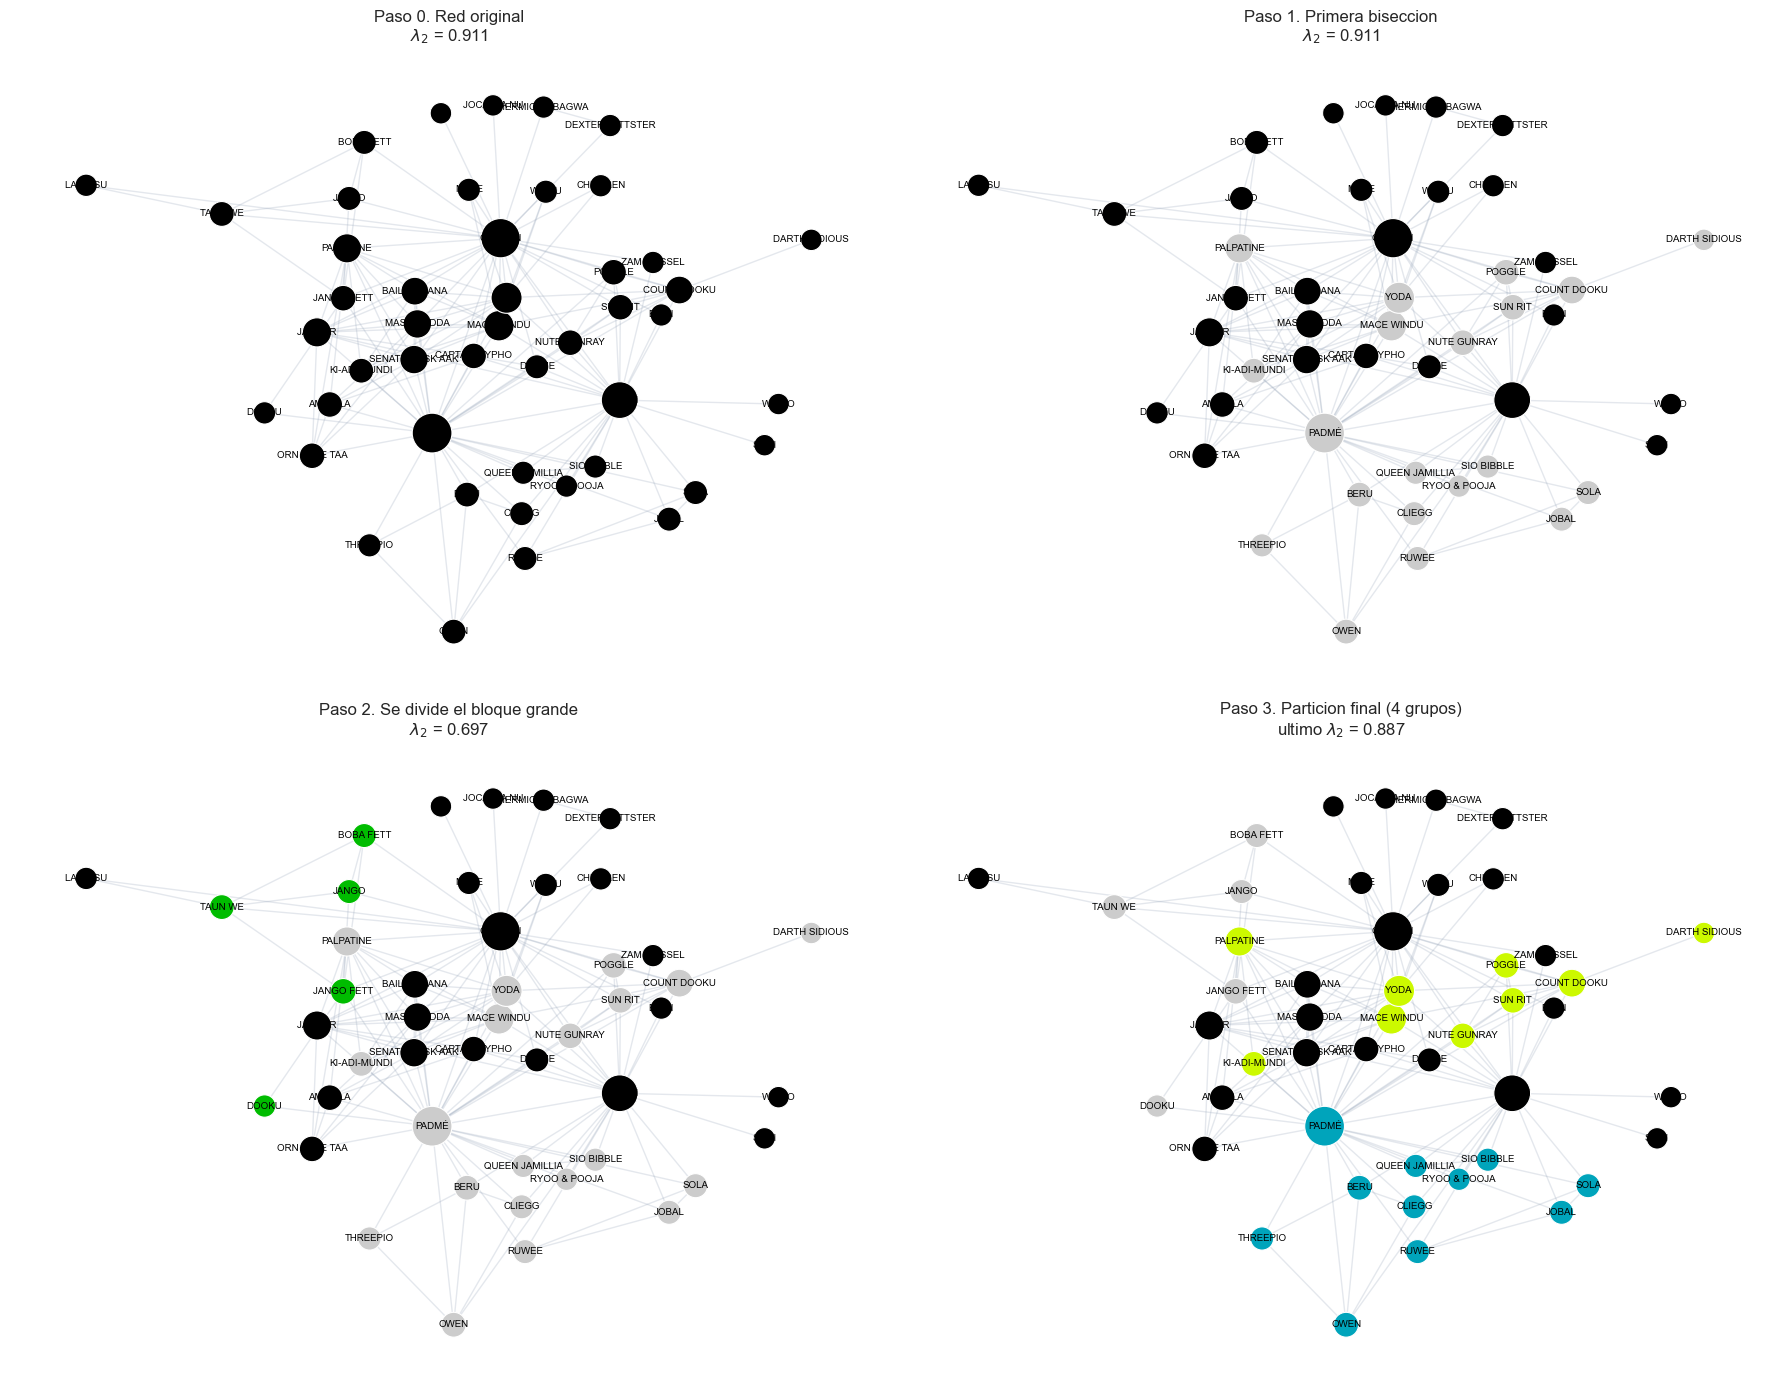

In [5]:
states_sw = [
    {
        "title": f"Paso 0. Red original\n$\lambda_2$ = {root_sw['lambda2']:.3f}",
        "groups": [set(G_sw.nodes())],
    },
    {
        "title": f"Paso 1. Primera biseccion\n$\lambda_2$ = {root_sw['lambda2']:.3f}",
        "groups": root_groups_sw,
    },
    {
        "title": f"Paso 2. Se divide el bloque grande\n$\lambda_2$ = {report_sw_a['lambda2']:.3f}",
        "groups": [set(part) for part in report_sw_a["groups"]] + [set(G_sw_b.nodes())],
    },
    {
        "title": f"Paso 3. Particion final (4 grupos)\nultimo $\lambda_2$ = {report_sw_b['lambda2']:.3f}",
        "groups": final_partition_sw,
    },
]

plot_partition_sequence(G_sw, labels_sw, states_sw, pos=pos_sw, ncols=2, figsize=(18, 14))

## 3. Comparacion con modularidad

En la actividad de modularidad aparecian 4 comunidades tambien, pero con una logica diferente.
La modularidad premia grupos con muchas aristas internas y pocas externas; el agrupamiento espectral con Laplaciana,
en cambio, busca cortes suaves guiados por el vector de Fiedler.

,grafo,metodo,grupos,Q
0,Star Wars completo,greedy_modularity_communities,4,0.3339
1,Star Wars completo,espectral laplaciano recursivo,4,0.1901


,grupo,nodos,aristas_internas,densidad,lambda_2,miembros
0,1,16,36,0.3000,1.0000,"ANAKIN, BERU, CAPTAIN TYPHO, CLIEGG, DORME, JOBAL, OWEN, PADMÉ, QUEEN JAMILLIA, RUWEE, RYOO & POOJA, SHMI, SIO BIBBLE, SOLA, THREEPIO, WATTO"
1,2,15,41,0.3905,0.8029,"AMIDALA, BAIL ORGANA, CHILDREN, COUNT DOOKU, DARTH SIDIOUS, JAR JAR, KI-ADI-MUNDI, MACE, MACE WINDU, MAS AMEDDA, ORN FREE TAA, PALPATINE, SENATOR ASK AAK, WINDU, YODA"
2,3,13,20,0.2564,0.7411,"BOBA FETT, DEXTER JETTSTER, DOOKU, ELAN, HERMIONE BAGWA, JANGO, JANGO FETT, JOCASTA NU, LAMA SU, OBI-WAN, PK-4, TAUN WE, ZAM WESSEL"
3,4,3,3,1.0000,6.0000,"NUTE GUNRAY, POGGLE, SUN RIT"


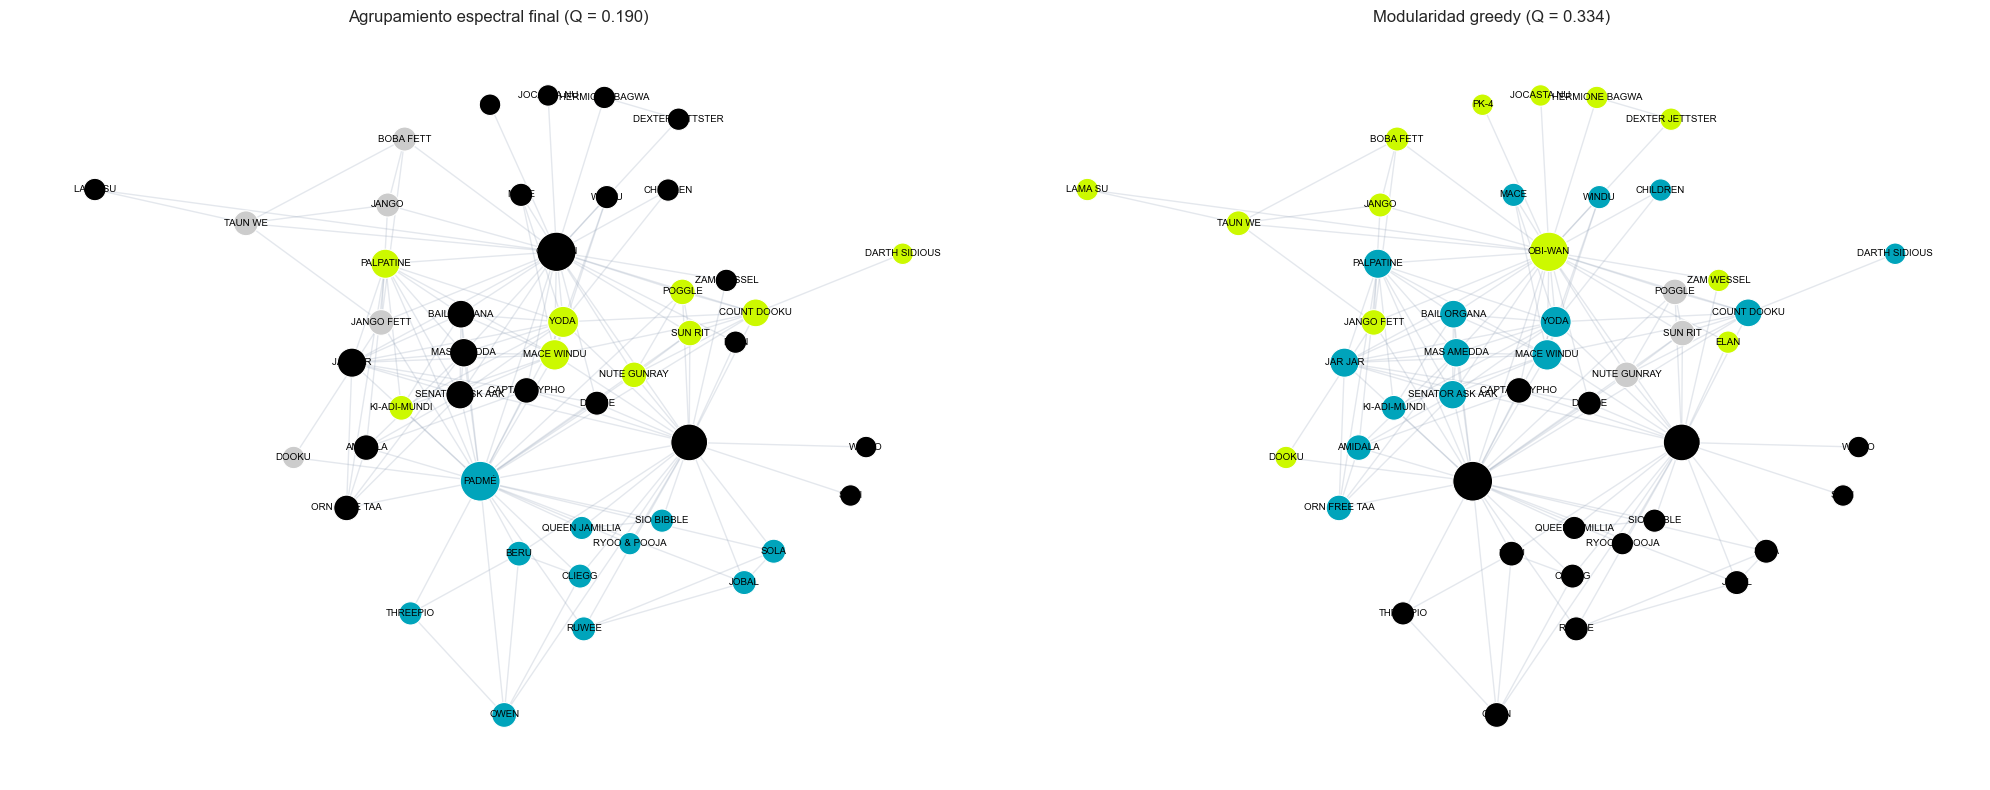

In [6]:
comunidades_mod_sw = sorted(list(greedy_modularity_communities(G_sw, weight="weight")), key=len, reverse=True)
q_spectral_sw = nx.algorithms.community.modularity(G_sw, final_partition_sw, weight="weight")
q_mod_sw = nx.algorithms.community.modularity(G_sw, comunidades_mod_sw, weight="weight")

comparacion_sw = comparison_table(
    [
        {
            "grafo": "Star Wars completo",
            "metodo": "greedy_modularity_communities",
            "grupos": len(comunidades_mod_sw),
            "Q": round(q_mod_sw, 4),
        },
        {
            "grafo": "Star Wars completo",
            "metodo": "espectral laplaciano recursivo",
            "grupos": len(final_partition_sw),
            "Q": round(q_spectral_sw, 4),
        },
    ]
)

display(comparacion_sw)
display(partition_summary(G_sw, comunidades_mod_sw, labels_sw, weight="weight"))

fig, axes = plt.subplots(1, 2, figsize=(20, 8))
draw_partition(
    axes[0],
    G_sw,
    final_partition_sw,
    labels_sw,
    title=f"Agrupamiento espectral final (Q = {q_spectral_sw:.3f})",
    pos=pos_sw,
)
draw_partition(
    axes[1],
    G_sw,
    comunidades_mod_sw,
    labels_sw,
    title=f"Modularidad greedy (Q = {q_mod_sw:.3f})",
    pos=pos_sw,
)
plt.tight_layout()
plt.show()

<!-- interpretacion-codex: comparacion-modularidad -->
### Lectura específica de la comparación con modularidad

La modularidad greedy obtiene $Q \approx 0.3339$, mientras que la partición espectral queda en $Q \approx 0.1901$. Esta diferencia indica que modularidad encuentra grupos con más peso interno del esperado por su modelo nulo.

En términos de la película, esto favorece una lectura por escenas y subtramas locales:

- el bloque ANAKIN-PADMÉ-Tatooine/Naboo se sostiene por escenas repetidas de romance, familia y duelo por SHMI;
- el bloque OBI-WAN-Kamino-investigación se sostiene por la secuencia de pistas, persecución y descubrimiento del ejército clon;
- el bloque político-jedi conecta Senado, Consejo Jedi y el inicio de la guerra;
- el núcleo NUTE GUNRAY-POGGLE-SUN RIT aparece como una comunidad muy pequeña pero extremadamente cerrada, coherente con el frente separatista.

Por eso modularidad no contradice al corte espectral: responde otra pregunta. El corte espectral describe el eje global de separación; modularidad identifica comunidades locales más densas.

## Conclusión del agrupamiento espectral

- Las agrupaciones espectrales sí tienen sentido, sobre todo como lectura de los puentes estructurales de la película. DARTH SIDIOUS queda como extremo de un polo porque casi toda su conectividad relevante está concentrada en el frente separatista; OBI-WAN queda del otro lado porque su ruta narrativa enlaza persecución, archivos Jedi, Kamino y Jango.
- La partición espectral final produce cuatro grupos de tamaños 22, 11, 9 y 5. El grupo más pequeño, Kamino/Jango, tiene densidad interna alta ($0.7000$), lo cual indica que esos personajes coaparecen de forma muy concentrada. Eso cuadra con la película: Kamino es una secuencia corta pero narrativamente muy cerrada.
- La partición por modularidad tiene $Q \approx 0.3339$, mayor que el $Q \approx 0.1901$ de la partición espectral. Si la pregunta es “¿qué describe mejor comunidades locales de coaparición?”, modularidad gana.
- Si la pregunta es “¿cuál es la fractura estructural global de la red?”, el agrupamiento espectral aporta otra lectura: muestra cómo la película oscila entre investigación/Kamino y el frente político-militar que desemboca en Geonosis.
- En otras palabras: modularidad gana para comunidades compactas; la Laplaciana gana para entender puentes, trayectorias narrativas y polarización global.

# Degree-corrected SBM

En esta sección se agrega un **modelo de bloques estocásticos corregido por grado** (*degree-corrected stochastic block model*, DC-SBM) para comparar dos particiones ya propuestas en la notebook:

1. la partición obtenida por **modularidad greedy**, guardada como `comunidades_mod_sw`;
2. la partición obtenida por **agrupamiento espectral recursivo**, guardada como `final_partition_sw`.

La idea no es volver a buscar comunidades desde cero. Aquí se toma cada partición $g$ como una hipótesis candidata y se evalúa qué tan verosímil es bajo el modelo corregido por grado.

El modelo separa dos efectos:

- $c_i$: propensión de grado del nodo $i$;
- $\omega_{rs}$: intensidad relativa de conexión entre los grupos $r$ y $s$.

Para una red no dirigida con matriz de adyacencia ponderada $A=(A_{ij})$, se usa la formulación de Poisson:

$$
A_{ij}\sim \operatorname{Poisson}
\left(
\omega_{g_i g_j}\frac{c_i c_j}{2m}
\right).
$$

En esta notebook, $A_{ij}$ se interpreta como peso de coaparición. Por tanto, si las aristas tienen atributo `weight`, se trabaja con una versión ponderada del modelo.

## Notación usada

Para una partición fija $g=(g_1,\ldots,g_n)$:

$$
k_i=\sum_j A_{ij}
$$

es el grado ponderado del nodo $i$. El estimador de máxima verosimilitud del parámetro de grado es

$$
\hat c_i=k_i.
$$

La masa de grado del grupo $r$ es

$$
\kappa_r=\sum_i \delta_{g_i r}k_i.
$$

El número ponderado de aristas dirigidas de grupo $r$ a grupo $s$ es

$$
m_{rs}
=
\sum_{ij}
\delta_{g_i r}\delta_{g_j s}A_{ij}.
$$

Como la red es no dirigida, $m_{rs}=m_{sr}$, pero $\kappa_r$ y $\kappa_s$ no tienen por qué ser iguales.

El estimador perfilado de la matriz de interacción comunitaria es

$$
\hat\omega_{rs}
=
\frac{2m\,m_{rs}}{\kappa_r\kappa_s}.
$$

Finalmente, la log-verosimilitud perfilada, salvo constantes que no dependen de $g$, es

$$
L(g)
=
\frac{1}{2}
\sum_{rs}
m_{rs}
\log\left(
\frac{m_{rs}}{\kappa_r\kappa_s}
\right).
$$

Como las constantes son las mismas para las dos particiones sobre la misma red, esta cantidad sirve para comparar cuál partición es más compatible con el DC-SBM.

## Pseudocódigo

```text
Entrada:
    G = red ponderada de coapariciones
    particiones = {
        "modularidad": comunidades_mod_sw,
        "espectral": final_partition_sw
    }

Para cada partición g:
    1. Calcular k_i = grado ponderado del nodo i.
    2. Calcular kappa_r = suma de k_i dentro del grupo r.
    3. Calcular m_rs = peso total observado entre grupos r y s.
       - Si una arista no dirigida queda dentro del mismo grupo, cuenta dos veces en m_rr.
       - Si una arista conecta grupos distintos, cuenta una vez en m_rs y una vez en m_sr.
    4. Estimar omega_hat_rs = 2m m_rs / (kappa_r kappa_s).
    5. Evaluar L(g) = 1/2 sum_rs m_rs log(m_rs / (kappa_r kappa_s)).
    6. Guardar tablas y visualizaciones.

Salida:
    Comparación entre partición de modularidad y partición espectral.
```

In [7]:
def normalize_partition(communities):
    """
    Convierte una lista de comunidades en una lista ordenada de conjuntos.

    La ordenación por tamaño descendente hace que las tablas sean más legibles.
    No cambia la partición matemática; solo cambia el nombre visual de los grupos.
    """
    return sorted([set(c) for c in communities], key=lambda c: (-len(c), sorted(map(str, c))))


def partition_to_lookup(communities):
    """
    Construye la asignación g_i.

    Devuelve:
        lookup[node] = r

    donde r es el índice entero del grupo al que pertenece el nodo.
    """
    lookup = {}
    for r, community in enumerate(communities):
        for node in community:
            lookup[node] = r
    return lookup


def safe_weight(edge_data, weight="weight"):
    """
    Extrae el peso de una arista.

    Si weight=None, se interpreta cada arista como peso 1.
    Si el atributo no existe, también se usa peso 1.
    """
    if weight is None:
        return 1.0
    return float(edge_data.get(weight, 1.0))


def compute_dcsbm_statistics(G, communities, partition_name, labels=None, weight="weight"):
    """
    Calcula los objetos del degree-corrected SBM para una partición fija g.

    Parámetros
    ----------
    G : networkx.Graph
        Red no dirigida. Puede ser ponderada.
    communities : list[set]
        Partición candidata de los nodos.
    partition_name : str
        Nombre de la partición para reportes.
    labels : dict, optional
        Diccionario node -> etiqueta visible.
    weight : str or None
        Atributo de peso. Si None, se usa una red no ponderada.

    Devuelve
    --------
    stats : dict
        Diccionario con:
        - k_i: grados ponderados.
        - kappa_r: masa de grado por grupo.
        - m_rs: matriz de pesos observados entre grupos.
        - omega_hat_rs: estimador perfilado de Omega.
        - L_profile: log-verosimilitud perfilada sin constantes.
    """
    communities = normalize_partition(communities)
    lookup = partition_to_lookup(communities)
    nodes = list(G.nodes())
    q = len(communities)

    missing_nodes = sorted(set(nodes) - set(lookup), key=str)
    extra_nodes = sorted(set(lookup) - set(nodes), key=str)
    if missing_nodes or extra_nodes:
        raise ValueError(
            "La partición no coincide con los nodos de G. "
            f"missing_nodes={missing_nodes}, extra_nodes={extra_nodes}"
        )

    # k_i = grado ponderado del nodo i
    k_i = {node: float(G.degree(node, weight=weight)) for node in nodes}

    # m = peso total no dirigido. En NetworkX, G.size(weight) suma cada arista una vez.
    m = float(G.size(weight=weight))
    if m <= 0:
        raise ValueError("La red no tiene peso total positivo.")

    # kappa_r = suma de grados ponderados dentro de cada grupo r.
    kappa_r = np.zeros(q, dtype=float)
    for node, degree in k_i.items():
        r = lookup[node]
        kappa_r[r] += degree

    # m_rs = sum_ij delta_{g_i r} delta_{g_j s} A_ij.
    #
    # En una red no dirigida sin lazos:
    # - una arista interna u--v dentro de r aporta A_uv + A_vu = 2w a m_rr;
    # - una arista cruzada entre r y s aporta w a m_rs y w a m_sr.
    m_rs = np.zeros((q, q), dtype=float)

    for u, v, edge_data in G.edges(data=True):
        w = safe_weight(edge_data, weight=weight)
        r = lookup[u]
        s = lookup[v]

        if u == v:
            # Caso raro: lazo. En una matriz de adyacencia no dirigida, se trata como contribución diagonal.
            m_rs[r, s] += 2.0 * w
        elif r == s:
            m_rs[r, r] += 2.0 * w
        else:
            m_rs[r, s] += w
            m_rs[s, r] += w

    # Verificación: sum_rs m_rs debe ser 2m.
    directed_total = float(m_rs.sum())
    if not np.isclose(directed_total, 2.0 * m):
        raise ArithmeticError(
            f"Inconsistencia en conteos: sum_rs m_rs={directed_total}, pero 2m={2.0*m}."
        )

    denominator = np.outer(kappa_r, kappa_r)

    with np.errstate(divide="ignore", invalid="ignore"):
        omega_hat_rs = (2.0 * m * m_rs) / denominator

    # Convención: si m_rs=0, entonces m_rs log(m_rs/(kappa_r kappa_s)) = 0.
    with np.errstate(divide="ignore", invalid="ignore"):
        profile_terms = np.where(
            m_rs > 0,
            0.5 * m_rs * np.log(m_rs / denominator),
            0.0,
        )

    L_profile = float(np.nansum(profile_terms))

    # Versión equivalente que incluye el factor 2m dentro del logaritmo.
    # Difiere por una constante común entre particiones de la misma red.
    with np.errstate(divide="ignore", invalid="ignore"):
        profile_terms_with_2m = np.where(
            m_rs > 0,
            0.5 * m_rs * np.log((2.0 * m * m_rs) / denominator),
            0.0,
        )
    L_profile_with_2m = float(np.nansum(profile_terms_with_2m))

    group_names = [f"G{r+1}" for r in range(q)]

    return {
        "partition_name": partition_name,
        "communities": communities,
        "lookup": lookup,
        "nodes": nodes,
        "labels": labels if labels is not None else {node: str(node) for node in nodes},
        "q": q,
        "m": m,
        "k_i": k_i,
        "kappa_r": kappa_r,
        "m_rs": m_rs,
        "omega_hat_rs": omega_hat_rs,
        "profile_terms": profile_terms,
        "L_profile": L_profile,
        "L_profile_with_2m": L_profile_with_2m,
        "group_names": group_names,
        "internal_directed_weight": float(np.trace(m_rs)),
        "external_directed_weight": float(m_rs.sum() - np.trace(m_rs)),
        "internal_share": float(np.trace(m_rs) / m_rs.sum()),
    }


def matrix_to_dataframe(matrix, group_names):
    """Convierte una matriz q x q en DataFrame con nombres de grupo."""
    return pd.DataFrame(matrix, index=group_names, columns=group_names)


def dcsbm_group_table(stats):
    """
    Tabla por grupo:
    - nodos;
    - kappa_r;
    - peso interno dirigido m_rr;
    - miembros.
    """
    rows = []
    labels = stats["labels"]

    for r, community in enumerate(stats["communities"]):
        rows.append(
            {
                "particion": stats["partition_name"],
                "grupo": f"G{r+1}",
                "nodos": len(community),
                "kappa_r": stats["kappa_r"][r],
                "m_rr": stats["m_rs"][r, r],
                "omega_hat_rr": stats["omega_hat_rs"][r, r],
                "miembros": ", ".join(sorted(labels[node] for node in community)),
            }
        )

    return pd.DataFrame(rows)


def dcsbm_comparison_table(stats_list):
    """Tabla comparativa entre particiones candidatas."""
    rows = []
    for stats in stats_list:
        rows.append(
            {
                "particion": stats["partition_name"],
                "q": stats["q"],
                "m": stats["m"],
                "sum_kappa_r": stats["kappa_r"].sum(),
                "sum_m_rs": stats["m_rs"].sum(),
                "peso_dirigido_interno": stats["internal_directed_weight"],
                "peso_dirigido_externo": stats["external_directed_weight"],
                "proporcion_interna": stats["internal_share"],
                "L_perfilada_sin_constantes": stats["L_profile"],
                "L_perfilada_con_2m": stats["L_profile_with_2m"],
            }
        )
    return pd.DataFrame(rows).sort_values("L_perfilada_sin_constantes", ascending=False).reset_index(drop=True)


def _matrix_color_limits(matrices):
    """Devuelve limites robustos para usar una misma escala de color."""
    finite_values = []
    for matrix in matrices:
        values = np.asarray(matrix, dtype=float)
        values = values[np.isfinite(values)]
        if values.size:
            finite_values.append(values)

    if not finite_values:
        return 0, 1

    values = np.concatenate(finite_values)
    vmin = min(0, values.min()) if values.min() >= 0 else values.min()
    vmax = values.max()
    if np.isclose(vmin, vmax):
        vmax = vmin + 1
    return vmin, vmax


def _format_matrix_value(value):
    if not np.isfinite(value):
        return "nan"
    abs_value = abs(value)
    if abs_value >= 100:
        return f"{value:.0f}"
    if abs_value >= 10:
        return f"{value:.1f}"
    if abs_value >= 1:
        return f"{value:.2f}"
    if abs_value == 0:
        return "0"
    return f"{value:.3f}"


def _annotated_heatmap(ax, matrix, group_names, title, cmap, norm, cbar_label=None):
    matrix = np.asarray(matrix, dtype=float)
    cmap = plt.get_cmap(cmap).copy()
    cmap.set_bad("#f2f4f8")

    image = ax.imshow(np.ma.masked_invalid(matrix), cmap=cmap, norm=norm, interpolation="nearest")
    ax.set_title(title, fontweight="bold", pad=12)
    ax.set_xticks(range(len(group_names)))
    ax.set_yticks(range(len(group_names)))
    ax.set_xticklabels(group_names, rotation=35, ha="right", rotation_mode="anchor")
    ax.set_yticklabels(group_names)
    ax.set_xlabel("Grupo destino s")
    ax.set_ylabel("Grupo origen r")

    ax.grid(False)
    ax.set_xticks(np.arange(-0.5, matrix.shape[1], 1), minor=True)
    ax.set_yticks(np.arange(-0.5, matrix.shape[0], 1), minor=True)
    ax.grid(which="minor", color="white", linewidth=1.6)
    ax.tick_params(which="minor", bottom=False, left=False)
    for spine in ax.spines.values():
        spine.set_visible(False)

    color_span = norm.vmax - norm.vmin
    for i in range(matrix.shape[0]):
        for j in range(matrix.shape[1]):
            value = matrix[i, j]
            if not np.isfinite(value):
                text_color = "#263238"
            else:
                intensity = 0 if color_span == 0 else (value - norm.vmin) / color_span
                text_color = "white" if intensity > 0.58 else "#263238"
            ax.text(j, i, _format_matrix_value(value), ha="center", va="center", color=text_color, fontsize=9, fontweight="semibold")

    cbar = ax.figure.colorbar(image, ax=ax, fraction=0.046, pad=0.04)
    if cbar_label:
        cbar.set_label(cbar_label)
    return image


def plot_dcsbm_matrices(stats_list):
    """
    Visualiza, para cada partición, las matrices m_rs y omega_hat_rs.

    m_rs muestra conteos/pesos observados entre grupos.
    omega_hat_rs muestra intensidad relativa estimada después de corregir por grado.
    """
    if not stats_list:
        return

    nrows = len(stats_list)
    fig, axes = plt.subplots(nrows, 2, figsize=(15, 4.8 * nrows), squeeze=False, constrained_layout=True)

    m_norm = Normalize(*_matrix_color_limits([stats["m_rs"] for stats in stats_list]))
    omega_norm = Normalize(*_matrix_color_limits([stats["omega_hat_rs"] for stats in stats_list]))

    for row, stats in enumerate(stats_list):
        group_names = stats["group_names"]

        _annotated_heatmap(
            axes[row, 0],
            stats["m_rs"],
            group_names,
            f"{stats['partition_name']}\n" + r"$m_{rs}$: pesos observados",
            cmap="YlGnBu",
            norm=m_norm,
            cbar_label="peso observado",
        )
        _annotated_heatmap(
            axes[row, 1],
            stats["omega_hat_rs"],
            group_names,
            f"{stats['partition_name']}\n" + r"$\hat{\omega}_{rs}$: intensidad corregida por grado",
            cmap="magma",
            norm=omega_norm,
            cbar_label="intensidad",
        )

    plt.show()


def plot_dcsbm_scores(stats_list):
    """Grafica la log-verosimilitud perfilada para las particiones comparadas."""
    if not stats_list:
        return

    names = np.array([stats["partition_name"] for stats in stats_list])
    scores = np.array([stats["L_profile"] for stats in stats_list], dtype=float)
    order = np.argsort(scores)[::-1]
    names = names[order]
    scores = scores[order]

    score_norm = Normalize(*_matrix_color_limits([scores]))
    colors = plt.get_cmap("viridis")(score_norm(scores))

    fig, ax = plt.subplots(figsize=(10, max(4.5, 0.72 * len(names))))
    bars = ax.barh(names, scores, color=colors, edgecolor="#263238", linewidth=0.8)
    ax.invert_yaxis()
    ax.axvline(0, color="#90a4ae", linewidth=1)
    ax.set_xlabel(r"$L(g)$ sin constantes")
    ax.set_title("Comparación DC-SBM de particiones candidatas", fontweight="bold", pad=12)
    ax.grid(axis="x", color="#d0d7de", linewidth=0.8, alpha=0.7)

    best_score = scores[0]
    labels = [f"{score:,.2f}  ({score - best_score:+.2f})" for score in scores]
    labels[0] = f"{best_score:,.2f}  (mejor)"
    ax.bar_label(bars, labels=labels, padding=5, fontsize=9)

    plt.tight_layout()
    plt.show()


def node_membership_table(stats):
    """Tabla nodo-grupo para revisar la asignación g_i."""
    labels = stats["labels"]
    rows = []
    for node in stats["nodes"]:
        rows.append(
            {
                "particion": stats["partition_name"],
                "nodo": labels[node],
                "grupo": f"G{stats['lookup'][node]+1}",
                "k_i": stats["k_i"][node],
            }
        )
    return pd.DataFrame(rows).sort_values(["grupo", "k_i", "nodo"], ascending=[True, False, True]).reset_index(drop=True)

## Evaluación de las dos particiones

Se evalúan las dos particiones ya construidas arriba: modularidad greedy y agrupamiento espectral recursivo. Ambas tienen $q=4$ grupos, así que la comparación bajo DC-SBM es directa.

La pregunta cambia respecto a la sección anterior. Ya no pregunto solamente si hay muchas aristas internas, sino si los pesos observados entre personajes son plausibles bajo un modelo que corrige por el grado de cada nodo. Esto importa porque PADMÉ, OBI-WAN y ANAKIN tienen grados muy altos; sin corrección por grado, esos personajes pueden dominar cualquier partición solo por aparecer mucho.

In [8]:
partitions_for_dcsbm = {
    "Modularidad greedy": comunidades_mod_sw,
    "Agrupamiento espectral": final_partition_sw,
}

q_values = {name: len(normalize_partition(partition)) for name, partition in partitions_for_dcsbm.items()}
print("Numero de grupos por particion:", q_values)

if len(set(q_values.values())) != 1:
    raise ValueError(
        "Las particiones no tienen el mismo numero de grupos. "
        "Para una comparacion directa, usa particiones con el mismo q."
    )

dcsbm_stats_sw = [
    compute_dcsbm_statistics(
        G_sw,
        communities=partition,
        partition_name=name,
        labels=labels_sw,
        weight="weight",
    )
    for name, partition in partitions_for_dcsbm.items()
]

comparacion_dcsbm_sw = dcsbm_comparison_table(dcsbm_stats_sw)
display(comparacion_dcsbm_sw)

Numero de grupos por particion: {'Modularidad greedy': 4, 'Agrupamiento espectral': 4}


,particion,q,m,sum_kappa_r,sum_m_rs,peso_dirigido_interno,peso_dirigido_externo,proporcion_interna,L_perfilada_sin_constantes,L_perfilada_con_2m
0,Modularidad greedy,4,232.0,464.0,464.0,302.0,162.0,0.650862,-1362.984106,61.469110
1,Agrupamiento espectral,4,232.0,464.0,464.0,242.0,222.0,0.521552,-1388.348164,36.105052


<!-- interpretacion-codex: evaluacion-dcsbm -->
### Lectura específica de la tabla DC-SBM

La partición de modularidad tiene $L(g)=-1362.9841$ y proporción interna $0.6509$. La partición espectral tiene $L(g)=-1388.3482$ y proporción interna $0.5216$.

La diferencia es importante porque el DC-SBM ya corrigió por grado. No está premiando simplemente que PADMÉ, OBI-WAN o ANAKIN aparezcan mucho; está preguntando si, después de tomar en cuenta esos grados altos, los bloques siguen explicando bien dónde cae el peso de las coapariciones.

La respuesta es sí para modularidad: concentra $302$ unidades de peso dirigido dentro de grupos, contra $242$ en la partición espectral. Esto hace sentido narrativo porque modularidad separa mejor los arcos cerrados de la película: romance/familia, investigación Kamino, política Jedi/Senado y separatistas.

## Matrices $m_{rs}$, $\kappa_r$ y $\hat\omega_{rs}$

La matriz $m_{rs}$ dice cuánta conexión observada hay entre grupos.

La matriz $\hat\omega_{rs}$ corrige esos pesos por la masa de grado $\kappa_r\kappa_s$. Por eso puede pasar que una partición tenga muchos pesos entre dos grupos, pero una intensidad corregida no tan alta si esos grupos contienen nodos muy populares.

Interpretación práctica:

- valores diagonales altos en $m_{rs}$: muchos pesos internos;
- valores diagonales altos en $\hat\omega_{rs}$: conexión interna mayor a la esperada después de corregir por grado;
- valores fuera de la diagonal altos en $\hat\omega_{rs}$: interacción fuerte entre dos comunidades distintas;
- si $\hat\omega_{rr}$ es claramente mayor que los valores fuera de la diagonal de la misma fila/columna, el grupo es asortativo: sus personajes se conectan más entre sí que con el resto, incluso después de considerar que algunos tienen mucho grado.

Modularidad greedy
kappa_r


,grupo,kappa_r
0,G1,179.0
1,G2,161.0
2,G3,98.0
3,G4,26.0


m_rs


,G1,G2,G3,G4
G1,122.0,26.0,23.0,8.0
G2,26.0,114.0,18.0,3.0
G3,23.0,18.0,54.0,3.0
G4,8.0,3.0,3.0,12.0


omega_hat_rs


...

,G1,G2,G3,G4
G1,120.0,42.0,43.0,8.0
G2,42.0,50.0,16.0,2.0
G3,43.0,16.0,56.0,0.0
G4,8.0,2.0,0.0,16.0


omega_hat_rs


,G1,G2,G3,G4
G1,1.2273,0.8318,0.8145,0.6703
G2,0.8318,1.9174,0.5869,0.3245
G3,0.8145,0.5869,1.9648,0.0000
G4,0.6703,0.3245,0.0000,10.9822


Resumen por grupo


,particion,grupo,nodos,kappa_r,m_rr,omega_hat_rr,miembros
0,Agrupamiento espectral,G1,22,213.0,120.0,1.2273,"AMIDALA, ANAKIN, BAIL ORGANA, CAPTAIN TYPHO, CHILDREN, DEXTER JETTSTER, DORME, ELAN, HERMIONE BAGWA, JAR JAR, JOCASTA NU, LAMA SU, MACE, MAS AMEDDA, OBI-WAN, ORN FREE TAA, PK-4, SENATOR ASK AAK, S..."
1,Agrupamiento espectral,G2,11,110.0,50.0,1.9174,"BERU, CLIEGG, JOBAL, OWEN, PADMÉ, QUEEN JAMILLIA, RUWEE, RYOO & POOJA, SIO BIBBLE, SOLA, THREEPIO"
2,Agrupamiento espectral,G3,9,115.0,56.0,1.9648,"COUNT DOOKU, DARTH SIDIOUS, KI-ADI-MUNDI, MACE WINDU, NUTE GUNRAY, PALPATINE, POGGLE, SUN RIT, YODA"
3,Agrupamiento espectral,G4,5,26.0,16.0,10.9822,"BOBA FETT, DOOKU, JANGO, JANGO FETT, TAUN WE"


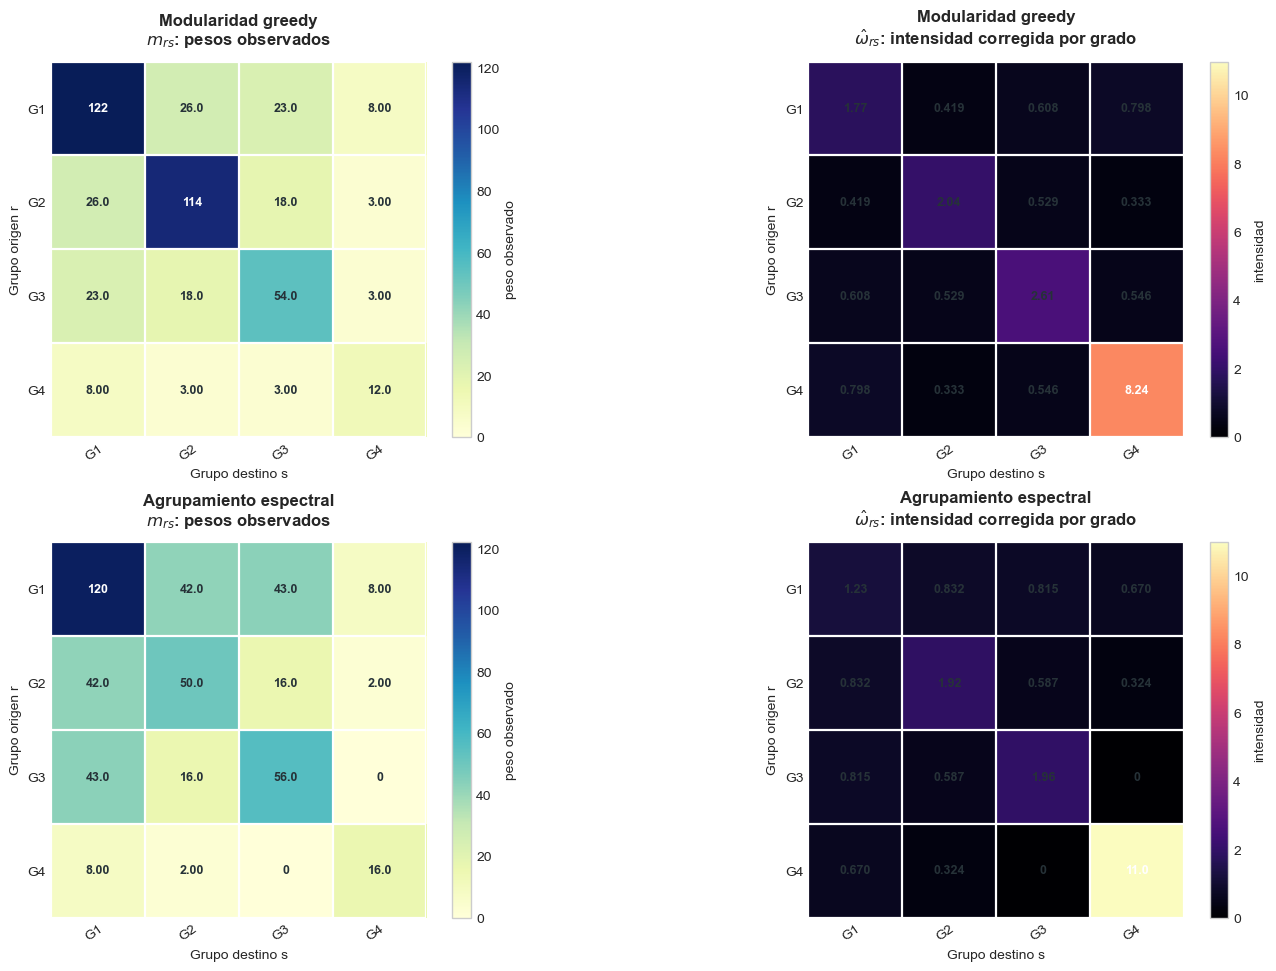

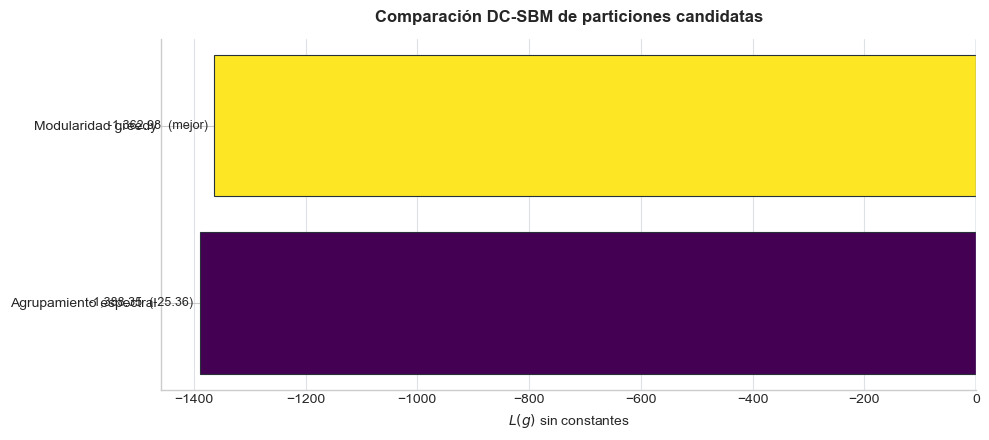

In [9]:
for stats in dcsbm_stats_sw:
    print("=" * 100)
    print(stats["partition_name"])
    print("kappa_r")
    display(pd.DataFrame({"grupo": stats["group_names"], "kappa_r": stats["kappa_r"]}))

    print("m_rs")
    display(matrix_to_dataframe(stats["m_rs"], stats["group_names"]))

    print("omega_hat_rs")
    display(matrix_to_dataframe(stats["omega_hat_rs"], stats["group_names"]).round(4))

    print("Resumen por grupo")
    display(dcsbm_group_table(stats).round({"kappa_r": 4, "m_rr": 4, "omega_hat_rr": 4}))

plot_dcsbm_matrices(dcsbm_stats_sw)
plot_dcsbm_scores(dcsbm_stats_sw)

<!-- interpretacion-codex: matrices-dcsbm -->
### Interpretación por bloques de las matrices DC-SBM

Para **modularidad greedy**, la diagonal de $\hat\omega$ es alta en todos los grupos: $G1=1.7667$, $G2=2.0407$, $G3=2.6089$ y $G4=8.2367$. Eso indica una partición asortativa: los personajes tienden a conectarse más dentro de su propio bloque que con otros bloques, incluso después de corregir por grado.

- **G1** reúne ANAKIN, PADMÉ, SHMI, WATTO, OWEN, BERU y el entorno Naboo/Tatooine. Tiene $m_{11}=122$ y $\kappa_1=179$. Es asortativo porque el romance, la familia Lars y el regreso a Tatooine concentran muchas coapariciones internas. Hace sentido que ANAKIN y PADMÉ estén juntos: su relación no es solo un vínculo individual, arrastra escenas completas de Naboo y Tatooine.
- **G2** junta AMIDALA, YODA, MACE WINDU, PALPATINE, JAR JAR, COUNT DOOKU y figuras del Senado/Jedi. Tiene $m_{22}=114$ y $\hat\omega_{22}=2.0407$. Es el bloque institucional: debate político, Consejo Jedi, autoridad republicana y amenaza separatista. PALPATINE y JAR JAR aparecen aquí porque su peso narrativo está en el Senado y en la transferencia de poderes de emergencia.
- **G3** junta OBI-WAN, JANGO FETT, TAUN WE, LAMA SU, DEXTER JETTSTER, JOCASTA NU y ZAM WESSEL. Tiene $m_{33}=54$ y $\hat\omega_{33}=2.6089$. Es el bloque detective/Kamino: aunque no es el más grande, su intensidad corregida es fuerte porque sus coapariciones están muy enfocadas alrededor de la investigación de OBI-WAN.
- **G4** contiene NUTE GUNRAY, POGGLE y SUN RIT. Tiene pocos nodos, pero $\hat\omega_{44}=8.2367$, el valor diagonal más alto. Es el caso más asortativo: un núcleo separatista pequeño, casi clique, con coapariciones muy concentradas.

Para **agrupamiento espectral**, también aparecen diagonales altas, pero el grupo $G1$ queda más mezclado: $m_{12}=42$ y $m_{13}=43$ son grandes. Eso explica por qué su $L(g)$ es peor: el corte espectral captura trayectorias globales, pero deja más peso entre bloques, sobre todo porque OBI-WAN, ANAKIN y PADMÉ funcionan como puentes entre subtramas.

## Visualización de las particiones con score DC-SBM

La siguiente figura conserva el layout usado previamente en la notebook. El título de cada red incluye la log-verosimilitud perfilada de la partición.

Como el valor absoluto de $L(g)$ incluye constantes omitidas, lo relevante aquí es la comparación entre particiones sobre la misma red.

En la visualización, la partición de modularidad debe leerse como bloques narrativos más compactos: el arco ANAKIN-PADMÉ-Tatooine/Naboo, el bloque Senado-Jedi, el bloque OBI-WAN-Kamino-investigación y el triángulo separatista NUTE GUNRAY-POGGLE-SUN RIT. La partición espectral, en cambio, enfatiza el camino global de la historia: investigación, romance/familia, política/guerra y Kamino.

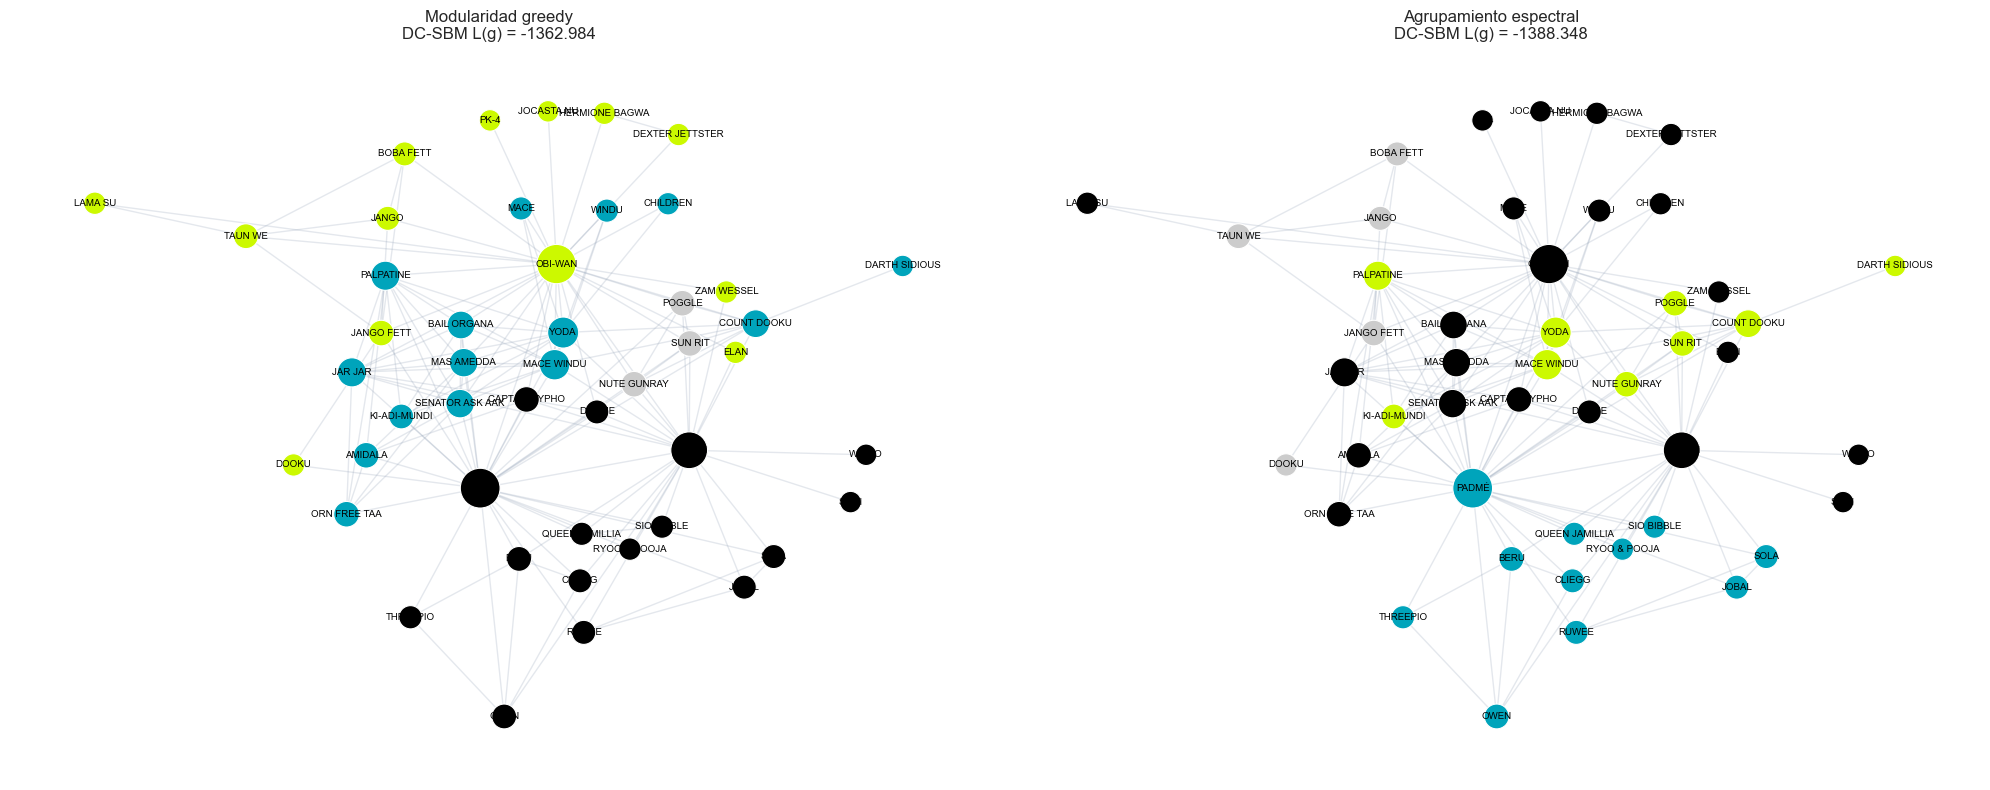

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(20, 8))

for ax, stats in zip(axes, dcsbm_stats_sw):
    draw_partition(
        ax,
        G_sw,
        stats["communities"],
        labels_sw,
        title=f"{stats['partition_name']}\nDC-SBM L(g) = {stats['L_profile']:.3f}",
        pos=pos_sw,
    )

plt.tight_layout()
plt.show()

<!-- interpretacion-codex: visualizacion-particiones -->
### Lectura de la figura de particiones

En la figura, la partición de modularidad se ve más “cerrada” porque sus colores siguen mejor las escenas repetidas de la película. El bloque ANAKIN-PADMÉ queda compacto; el bloque OBI-WAN-Kamino queda separado; y el núcleo separatista aparece pequeño pero muy cohesivo.

La partición espectral es útil de otra forma: muestra cómo ciertos personajes sirven de pasarela entre regiones de la red. OBI-WAN no solo pertenece a Kamino; también conecta con Jedi, archivos, persecución y Geonosis. PADMÉ no solo pertenece a Naboo; también conecta Senado, Anakin y el clímax de la arena. Esa función de puente hace que el corte espectral sea narrativamente interesante aunque estadísticamente pierda frente al DC-SBM.

## Revisión de asignaciones nodo-grupo

Estas tablas permiten revisar explícitamente el vector $g$. Es decir, muestran a qué grupo pertenece cada personaje bajo cada partición y cuál es su grado ponderado $k_i$.

Esta revisión es necesaria porque un grupo puede verse estadísticamente bueno pero narrativamente raro. Por ejemplo, COUNT DOOKU puede aparecer cerca del bloque político-jedi en modularidad porque comparte escenas institucionales y de confrontación, mientras que el corte espectral puede separarlo distinto si funciona como puente hacia Geonosis. La tabla ayuda a detectar esos casos.

In [11]:
for stats in dcsbm_stats_sw:
    print("=" * 100)
    print(stats["partition_name"])
    display(node_membership_table(stats))

Modularidad greedy


,particion,nodo,grupo,k_i
0,Modularidad greedy,PADMÉ,G1,63.0
1,Modularidad greedy,ANAKIN,G1,56.0
2,Modularidad greedy,OWEN,G1,9.0
3,Modularidad greedy,CAPTAIN TYPHO,G1,7.0
4,Modularidad greedy,BERU,G1,6.0
5,Modularidad greedy,JOBAL,G1,6.0
6,Modularidad greedy,SOLA,G1,6.0
7,Modularidad greedy,RUWEE,G1,5.0
8,Modularidad greedy,CLIEGG,G1,4.0
9,Modularidad greedy,DORME,G1,4.0


Agrupamiento espectral


,particion,nodo,grupo,k_i
0,Agrupamiento espectral,OBI-WAN,G1,57.0
1,Agrupamiento espectral,ANAKIN,G1,56.0
2,Agrupamiento espectral,JAR JAR,G1,17.0
3,Agrupamiento espectral,MAS AMEDDA,G1,13.0
4,Agrupamiento espectral,SENATOR ASK AAK,G1,11.0
5,Agrupamiento espectral,BAIL ORGANA,G1,9.0
6,Agrupamiento espectral,ORN FREE TAA,G1,8.0
7,Agrupamiento espectral,CAPTAIN TYPHO,G1,7.0
8,Agrupamiento espectral,AMIDALA,G1,6.0
9,Agrupamiento espectral,LAMA SU,G1,5.0


<!-- interpretacion-codex: asignaciones -->
### Lectura específica de las asignaciones

Los grados ponderados más altos son PADMÉ ($63$), OBI-WAN ($57$) y ANAKIN ($56$). Estos tres personajes son los motores estructurales de la red:

- PADMÉ conecta política, romance y Naboo/Tatooine;
- OBI-WAN conecta el misterio de Kamino con Jango y la revelación separatista;
- ANAKIN conecta el arco emocional con PADMÉ, SHMI y el mundo Jedi.

La partición de modularidad separa mejor esos roles: PADMÉ y ANAKIN quedan en el bloque emocional/familiar, OBI-WAN queda en el bloque de investigación, y YODA/MACE/PALPATINE quedan en el bloque político-jedi. Eso explica por qué la partición gana bajo DC-SBM: no solo agrupa personajes populares, sino que ubica a cada protagonista en la subtrama donde sus coapariciones son más densas.

## Interpretación

La partición con mayor $L(g)$ es la más compatible con el **degree-corrected stochastic block model** entre las dos candidatas evaluadas.

Esto no significa necesariamente que sea la mejor partición narrativamente. Significa algo más específico:

$$
	ext{mejor }L(g)
\quad\Longleftrightarrow\quad
	ext{mejor ajuste estadístico bajo el DC-SBM}.
$$

La diferencia frente a modularidad es conceptual:

- la **modularidad** compara contra un modelo nulo de configuración y premia exceso de aristas internas;
- el **DC-SBM** estima explícitamente una matriz $\Omega$ de interacción entre grupos y corrige por heterogeneidad de grado usando $c_i$;
- el **agrupamiento espectral** no maximiza directamente esta verosimilitud, sino que usa la geometría de la Laplaciana para encontrar cortes estructurales.

En esta película, la corrección por grado es clave: PADMÉ ($k_i=63$), OBI-WAN ($k_i=57$) y ANAKIN ($k_i=56$) son personajes tan centrales que generan muchas coapariciones por presencia narrativa. El DC-SBM pregunta si, además de esa centralidad individual, hay bloques que concentran interacciones de forma sistemática.

In [12]:
winner = max(dcsbm_stats_sw, key=lambda stats: stats["L_profile"])
loser = min(dcsbm_stats_sw, key=lambda stats: stats["L_profile"])
delta_L = winner["L_profile"] - loser["L_profile"]

print("Mejor particion bajo DC-SBM:")
print(f"  {winner['partition_name']}")
print(f"  L(g) = {winner['L_profile']:.6f}")
print()
print("Comparacion:")
print(f"  Diferencia de log-verosimilitud perfilada: Delta L = {delta_L:.6f}")
print()
print(
    "Lectura: si Delta L > 0, la particion ganadora concentra mejor los patrones "
    "de conexion entre grupos despues de corregir por los grados ponderados de los nodos."
)

Mejor particion bajo DC-SBM:
  Modularidad greedy
  L(g) = -1362.984106

Comparacion:
  Diferencia de log-verosimilitud perfilada: Delta L = 25.364058

Lectura: si Delta L > 0, la particion ganadora concentra mejor los patrones de conexion entre grupos despues de corregir por los grados ponderados de los nodos.


## Interpretación final de la comparación DC-SBM

Con las dos particiones candidatas evaluadas bajo el **degree-corrected stochastic block model** con formulación Poisson, se obtuvo:

$$
L(g_{\mathrm{mod}}) = -1362.984106,
\qquad
L(g_{\mathrm{spec}}) = -1388.348164.
$$

Por tanto,

$$
\Delta L
=
L(g_{\mathrm{mod}})-L(g_{\mathrm{spec}})
=
25.364058.
$$

Como $\Delta L>0$, la partición por **modularidad greedy** tiene mayor log-verosimilitud perfilada que la partición por **agrupamiento espectral**. En términos del cociente de verosimilitudes, ignorando las mismas constantes aditivas para ambas particiones,

$$
rac{P(A\mid \hat\Omega_{\mathrm{mod}},\hat c,g_{\mathrm{mod}})}
{P(A\mid \hat\Omega_{\mathrm{spec}},\hat c,g_{\mathrm{spec}})}
=
\exp(\Delta L)
\approx
1.0363	imes 10^{11}.
$$

Equivalente en escala decimal:

$$
\log_{10}\left(\exp(\Delta L)
ight)
\approx
11.0155.
$$

Esto significa que, bajo este modelo, la red observada queda mucho mejor explicada por la partición de **modularidad greedy**. La razón narrativa es clara: modularidad separa bloques de coaparición muy cerrados, como el arco ANAKIN-PADMÉ-Tatooine/Naboo, el bloque OBI-WAN-Kamino-investigación y el pequeño núcleo separatista NUTE GUNRAY-POGGLE-SUN RIT.

La frase precisa es:

> Dada la partición, los conteos de aristas $A_{ij}$ se modelan como variables Poisson independientes con medias $\lambda_{ij}=\omega_{g_i g_j}k_i k_j/(2m)$.

La partición no “viene de una Poisson”; lo que se modela con Poisson son los conteos de aristas entre pares de nodos. La partición $g$ determina qué parámetro $\omega_{rs}$ aplica a cada par de grupos.

En resumen:

$$
boxed{
L(g_{\mathrm{mod}})>L(g_{\mathrm{spec}})
\quad\Rightarrow\quad
	ext{la partición greedy modularity es preferida por el DC-SBM Poisson.}
}
$$

In [13]:
# Resumen numerico final de la comparacion DC-SBM
L_modularidad_greedy = -1362.984106000000
L_agrupamiento_espectral = -1388.348164000000
Delta_L = L_modularidad_greedy - L_agrupamiento_espectral
likelihood_ratio = np.exp(Delta_L)
log10_likelihood_ratio = Delta_L / np.log(10)

print("Resumen numerico DC-SBM")
print(f"L(g_modularidad_greedy)      = {L_modularidad_greedy:.6f}")
print(f"L(g_agrupamiento_espectral) = {L_agrupamiento_espectral:.6f}")
print(f"Delta L                     = {Delta_L:.6f}")
print(f"exp(Delta L)                = {likelihood_ratio:.4e}")
print(f"log10(exp(Delta L))         = {log10_likelihood_ratio:.4f}")


Resumen numerico DC-SBM
L(g_modularidad_greedy)      = -1362.984106
L(g_agrupamiento_espectral) = -1388.348164
Delta L                     = 25.364058
exp(Delta L)                = 1.0363e+11
log10(exp(Delta L))         = 11.0155


# Simulación generativa con el DC-SBM ajustado

Ahora usamos los parámetros estimados en la sección anterior para generar una red sintética. La idea es tomar la partición ganadora bajo DC-SBM y simular una nueva matriz de adyacencia ponderada $A^{\mathrm{sim}}$ con

$$
A_{ij}^{\mathrm{sim}}\sim \operatorname{Poisson}(\lambda_{ij}),
\qquad
\lambda_{ij}
=
\hat\omega_{g_i g_j}
rac{k_i k_j}{2m}.
$$

Aquí:

- $g_i$ es la comunidad del nodo $i$ bajo la partición ganadora;
- $k_i$ es el grado ponderado observado del nodo $i$;
- $m$ es el peso total no dirigido de la red observada;
- $\hat\omega_{rs}$ es la matriz de intensidades estimada por máxima verosimilitud perfilada.

La simulación no prueba que la red real haya sido generada por este modelo. Sirve para revisar qué tipo de película-red produciría el modelo si solo conociera grados individuales y afinidades entre bloques. Si el modelo reproduce lo grueso pero falla en PADMÉ, OBI-WAN o ANAKIN, eso indica que esos personajes tienen funciones narrativas más específicas que una regla de bloques y grados.

## Pseudocódigo de simulación

```text
Entrada:
    stats = resultados DC-SBM de la partición ganadora
    nodos = nodos originales
    k_i = grados ponderados observados
    omega_hat_rs = matriz estimada de intensidades entre grupos
    g_i = asignación de grupo de cada nodo
    m = peso total observado

Para cada par no dirigido de nodos i < j:
    1. Identificar sus grupos r = g_i y s = g_j.
    2. Calcular lambda_ij = omega_hat_rs * k_i * k_j / (2m).
    3. Simular w_ij ~ Poisson(lambda_ij).
    4. Si w_ij > 0, agregar arista i--j con peso w_ij.

Salida:
    Una red sintética G_sim generada bajo el DC-SBM ajustado.
```

Como la red original no usa lazos, esta simulación omite lazos. Por eso las cantidades esperadas diagonales se calculan con la misma convención: solo pares $i<j$.

En términos narrativos, la simulación no “sabe” que ANAKIN y PADMÉ tienen una historia romántica, ni que OBI-WAN sigue una investigación. Solo sabe que esos nodos tienen grados altos y que sus grupos tienen ciertas intensidades $\hat\omega_{rs}$. Por eso las diferencias entre observado y simulado son informativas: señalan qué partes de la trama son más específicas que el patrón estadístico promedio.

In [14]:

def aggregate_m_rs_under_fixed_partition(G, fitted_stats, weight="weight"):
    """
    Calcula m_rs para una red G usando la misma partición de fitted_stats.

    Esta función permite comparar la red observada, la red esperada y una red simulada
    bajo exactamente la misma asignación g_i.
    """
    q = fitted_stats["q"]
    lookup = fitted_stats["lookup"]
    m_rs = np.zeros((q, q), dtype=float)

    for u, v, edge_data in G.edges(data=True):
        w = safe_weight(edge_data, weight=weight)
        r = lookup[u]
        s = lookup[v]

        if u == v:
            m_rs[r, s] += 2.0 * w
        elif r == s:
            m_rs[r, r] += 2.0 * w
        else:
            m_rs[r, s] += w
            m_rs[s, r] += w

    return m_rs


def expected_m_rs_no_loops(fitted_stats):
    """
    Calcula E[m_rs] bajo el DC-SBM ajustado, omitiendo lazos.

    En el modelo teórico con lazos permitidos, la esperanza reproduce exactamente
    m_rs bajo el estimador perfilado. En esta notebook omitimos lazos para mantener
    una red visual comparable con la red original; por eso la diagonal puede quedar
    ligeramente por debajo del m_rr observado.
    """
    nodes = fitted_stats["nodes"]
    lookup = fitted_stats["lookup"]
    k_i = fitted_stats["k_i"]
    omega_hat_rs = fitted_stats["omega_hat_rs"]
    m = fitted_stats["m"]
    q = fitted_stats["q"]

    expected = np.zeros((q, q), dtype=float)

    for a, u in enumerate(nodes):
        for v in nodes[a + 1:]:
            r = lookup[u]
            s = lookup[v]
            lambda_ij = omega_hat_rs[r, s] * k_i[u] * k_i[v] / (2.0 * m)

            if r == s:
                expected[r, r] += 2.0 * lambda_ij
            else:
                expected[r, s] += lambda_ij
                expected[s, r] += lambda_ij

    return expected


def simulate_dcsbm_graph(fitted_stats, seed=2026, weight="weight"):
    """
    Simula una red ponderada no dirigida desde el DC-SBM Poisson ajustado.

    Cada peso simulado w_ij representa el número de aristas de Poisson entre i y j.
    Para visualizarlo en NetworkX, se guarda como atributo `weight`.
    """
    rng = np.random.default_rng(seed)
    nodes = fitted_stats["nodes"]
    lookup = fitted_stats["lookup"]
    k_i = fitted_stats["k_i"]
    omega_hat_rs = fitted_stats["omega_hat_rs"]
    m = fitted_stats["m"]

    G_sim = nx.Graph()
    for node in nodes:
        # Conserva atributos disponibles del nodo original, si existen.
        G_sim.add_node(node, **G_sw.nodes[node])

    lambda_rows = []

    for a, u in enumerate(nodes):
        for v in nodes[a + 1:]:
            r = lookup[u]
            s = lookup[v]
            lambda_ij = omega_hat_rs[r, s] * k_i[u] * k_i[v] / (2.0 * m)
            simulated_weight = rng.poisson(lambda_ij)

            lambda_rows.append(
                {
                    "u": fitted_stats["labels"][u],
                    "v": fitted_stats["labels"][v],
                    "grupo_u": f"G{r+1}",
                    "grupo_v": f"G{s+1}",
                    "lambda_ij": lambda_ij,
                    "peso_simulado": simulated_weight,
                }
            )

            if simulated_weight > 0:
                G_sim.add_edge(u, v, **{weight: float(simulated_weight)})

    lambda_df = pd.DataFrame(lambda_rows)
    return G_sim, lambda_df


def summarize_simulated_network(G_sim, fitted_stats, G_observed=None, weight="weight"):
    """Resumen global de una red simulada."""
    m_rs_sim = aggregate_m_rs_under_fixed_partition(G_sim, fitted_stats, weight=weight)
    total_directed = float(m_rs_sim.sum())
    internal_directed = float(np.trace(m_rs_sim))

    rows = [
        {
            "red": "simulada",
            "nodos": G_sim.number_of_nodes(),
            "aristas_no_dirigidas_con_peso_positivo": G_sim.number_of_edges(),
            "peso_total_no_dirigido": G_sim.size(weight=weight),
            "peso_total_dirigido": total_directed,
            "peso_interno_dirigido": internal_directed,
            "proporcion_interna": internal_directed / total_directed if total_directed > 0 else np.nan,
        }
    ]

    if G_observed is not None:
        m_rs_obs = aggregate_m_rs_under_fixed_partition(G_observed, fitted_stats, weight=weight)
        obs_total_directed = float(m_rs_obs.sum())
        obs_internal_directed = float(np.trace(m_rs_obs))
        rows.insert(
            0,
            {
                "red": "observada",
                "nodos": G_observed.number_of_nodes(),
                "aristas_no_dirigidas_con_peso_positivo": G_observed.number_of_edges(),
                "peso_total_no_dirigido": G_observed.size(weight=weight),
                "peso_total_dirigido": obs_total_directed,
                "peso_interno_dirigido": obs_internal_directed,
                "proporcion_interna": obs_internal_directed / obs_total_directed if obs_total_directed > 0 else np.nan,
            },
        )

    return pd.DataFrame(rows)


def block_comparison_table(fitted_stats, G_sim, weight="weight"):
    """Compara m_rs observado, esperado y simulado bajo la partición ajustada."""
    observed = fitted_stats["m_rs"]
    expected = expected_m_rs_no_loops(fitted_stats)
    simulated = aggregate_m_rs_under_fixed_partition(G_sim, fitted_stats, weight=weight)
    group_names = fitted_stats["group_names"]

    rows = []
    for r in range(fitted_stats["q"]):
        for s in range(fitted_stats["q"]):
            rows.append(
                {
                    "bloque": f"{group_names[r]}-{group_names[s]}",
                    "m_rs_observado": observed[r, s],
                    "E_m_rs_modelo_sin_lazos": expected[r, s],
                    "m_rs_simulado": simulated[r, s],
                    "simulado_menos_esperado": simulated[r, s] - expected[r, s],
                    "simulado_menos_observado": simulated[r, s] - observed[r, s],
                }
            )
    return pd.DataFrame(rows)


In [15]:

# Seleccionamos la partición ganadora bajo DC-SBM.
fitted_stats = winner
print(f"Partición usada para simular: {fitted_stats['partition_name']}")
print(f"L(g) = {fitted_stats['L_profile']:.6f}")

# Una simulación individual para visualizar.
G_dcsbm_sim_sw, lambda_ij_table_sw = simulate_dcsbm_graph(fitted_stats, seed=2026, weight="weight")

print("Resumen observado vs. simulado")
display(summarize_simulated_network(G_dcsbm_sim_sw, fitted_stats, G_observed=G_sw, weight="weight").round(4))

print("Comparación por bloques m_rs")
display(block_comparison_table(fitted_stats, G_dcsbm_sim_sw, weight="weight").round(4))

print("Pares con mayor intensidad esperada lambda_ij")
display(
    lambda_ij_table_sw
    .sort_values("lambda_ij", ascending=False)
    .head(12)
    .round({"lambda_ij": 4})
)


Partición usada para simular: Modularidad greedy
L(g) = -1362.984106
Resumen observado vs. simulado


,red,nodos,aristas_no_dirigidas_con_peso_positivo,peso_total_no_dirigido,peso_total_dirigido,peso_interno_dirigido,proporcion_interna
0,observada,47,148,232.0,464.0,302.0,0.6509
1,simulada,47,131,215.0,430.0,252.0,0.5860


Comparación por bloques m_rs


,bloque,m_rs_observado,E_m_rs_modelo_sin_lazos,m_rs_simulado,simulado_menos_esperado,simulado_menos_observado
0,G1-G1,122.0,93.6979,96.0,2.3021,-26.0
1,G1-G2,26.0,26.0000,27.0,1.0000,1.0
2,G1-G3,23.0,23.0000,30.0,7.0000,7.0
3,G1-G4,8.0,8.0000,7.0,-1.0000,-1.0
4,G2-G1,26.0,26.0000,27.0,1.0000,1.0
5,G2-G2,114.0,102.3234,102.0,-0.3234,-12.0
6,G2-G3,18.0,18.0000,20.0,2.0000,2.0
7,G2-G4,3.0,3.0000,1.0,-2.0000,-2.0
8,G3-G1,23.0,23.0000,30.0,7.0000,7.0
9,G3-G2,18.0,18.0000,20.0,2.0000,2.0


Pares con mayor intensidad esperada lambda_ij


,u,v,grupo_u,grupo_v,lambda_ij,peso_simulado
73,ANAKIN,PADMÉ,G1,G1,13.4333,15
873,OBI-WAN,PADMÉ,G3,G1,4.7083,4
70,ANAKIN,OBI-WAN,G1,G3,4.1852,9
826,MACE WINDU,YODA,G2,G2,2.9686,5
885,OBI-WAN,TAUN WE,G3,G3,2.5639,2
625,JANGO FETT,OBI-WAN,G3,G3,2.2434,0
910,OWEN,PADMÉ,G1,G1,2.1589,3
959,PALPATINE,YODA,G2,G2,2.1374,3
673,JAR JAR,YODA,G2,G2,2.0187,4
811,MACE WINDU,PALPATINE,G2,G2,1.9791,2


<!-- interpretacion-codex: simulacion-resumen -->
### Interpretación de la simulación individual

La partición usada para simular es **Modularidad greedy**, la ganadora bajo DC-SBM.

La red observada tiene $148$ aristas positivas y peso total no dirigido $232$. La red simulada tiene $131$ aristas positivas y peso total $215$. Esto significa que esta simulación particular conserva bastante estructura, pero sale menos densa que la película real.

La proporción interna baja de $0.6509$ observada a $0.5860$ simulada. En palabras: el modelo genera conexiones dentro de los bloques, pero en esta corrida no reproduce toda la fuerza interna de las subtramas reales. La película parece más cerrada por arcos narrativos de lo que una simulación Poisson típica produce.

Los pares con mayor $\lambda_{ij}$ también son narrativamente razonables:

- ANAKIN-PADMÉ tiene $\lambda\approx13.43$, el valor más alto, porque ambos tienen grados altos y pertenecen al mismo bloque emocional/familiar;
- OBI-WAN-PADMÉ y ANAKIN-OBI-WAN aparecen altos porque son protagonistas que conectan subtramas principales;
- MACE WINDU-YODA, PALPATINE-YODA y JAR JAR-YODA aparecen dentro del bloque institucional, reflejando el peso del Senado y del Consejo Jedi.

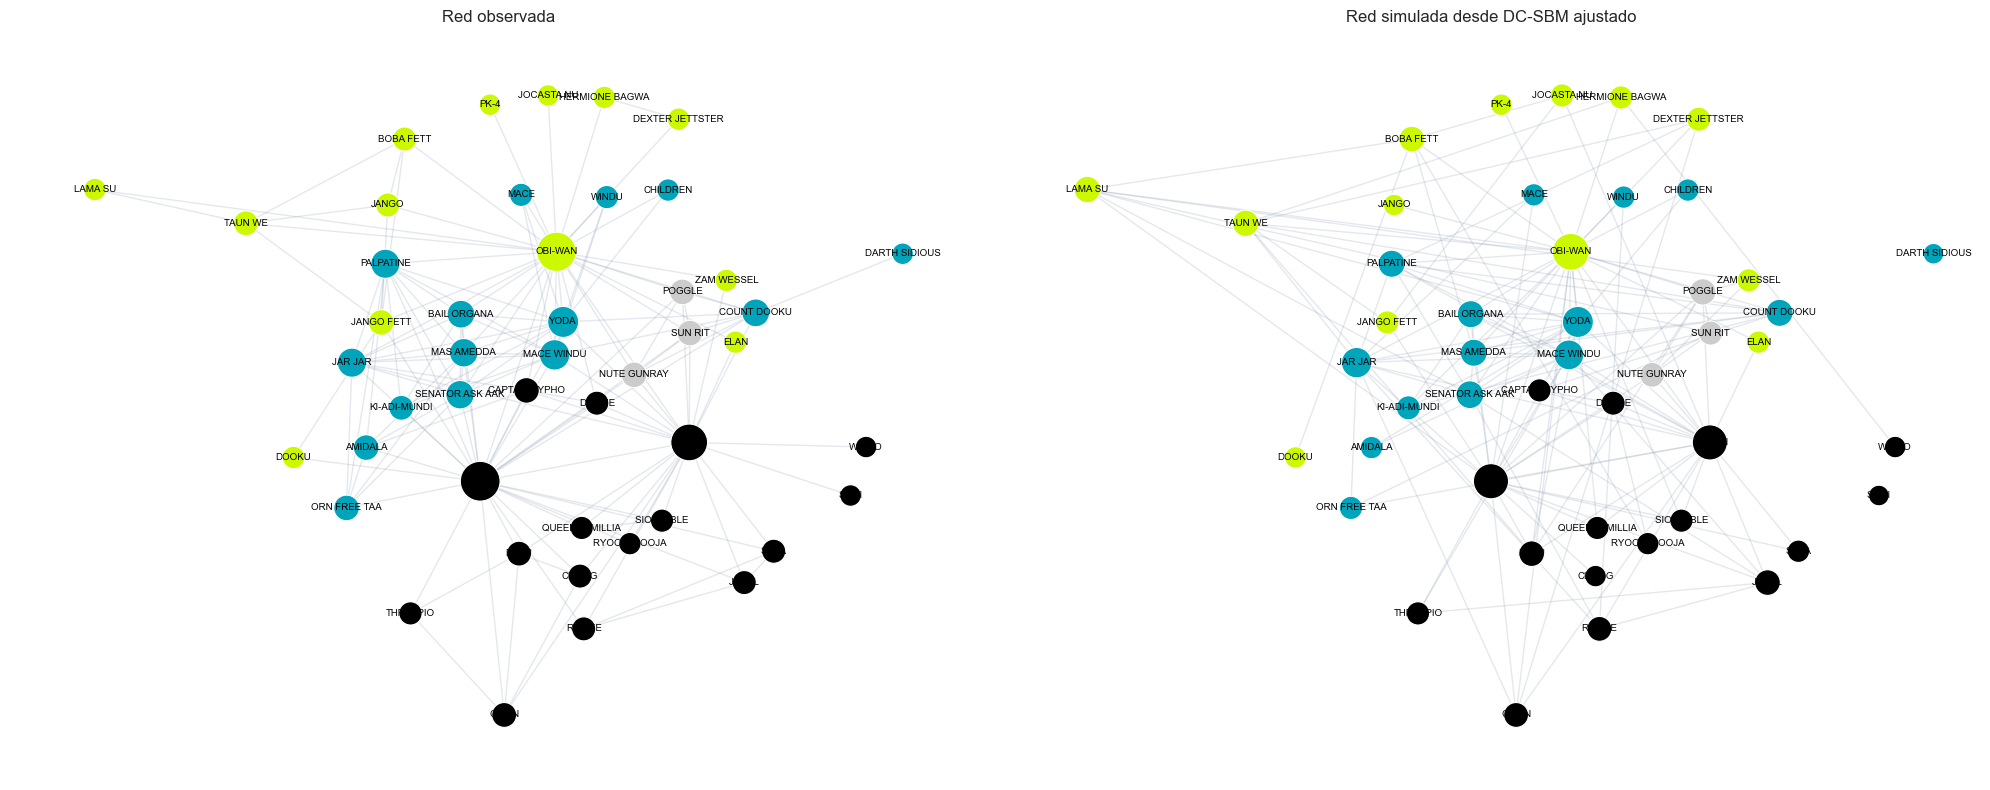

In [16]:

# Visualización: red observada vs. una red simulada desde el DC-SBM ajustado.
fig, axes = plt.subplots(1, 2, figsize=(20, 8))

for ax, graph, title in [
    (axes[0], G_sw, "Red observada"),
    (axes[1], G_dcsbm_sim_sw, "Red simulada desde DC-SBM ajustado"),
]:
    draw_partition(
        ax,
        graph,
        fitted_stats["communities"],
        labels_sw,
        title=title,
        pos=pos_sw,
    )

plt.tight_layout()
plt.show()


<!-- interpretacion-codex: red-simulada -->
### Lectura de la red observada vs. simulada

La red simulada reproduce la idea general de “personajes centrales con muchas conexiones”, pero pierde parte del cierre narrativo de la red observada. En la película real, PADMÉ, ANAKIN y OBI-WAN no son solo nodos de alto grado: cada uno organiza escenas completas.

Por eso la simulación puede colocar pesos razonables alrededor de ellos, pero no siempre recupera la misma geometría visual. El DC-SBM sabe que ANAKIN y PADMÉ deberían conectarse mucho; no sabe que esa conexión es el centro emocional de la película. Sabe que OBI-WAN y JANGO/Kamino deberían tener afinidad; no sabe que esa ruta funciona como investigación causal que revela el ejército clon.

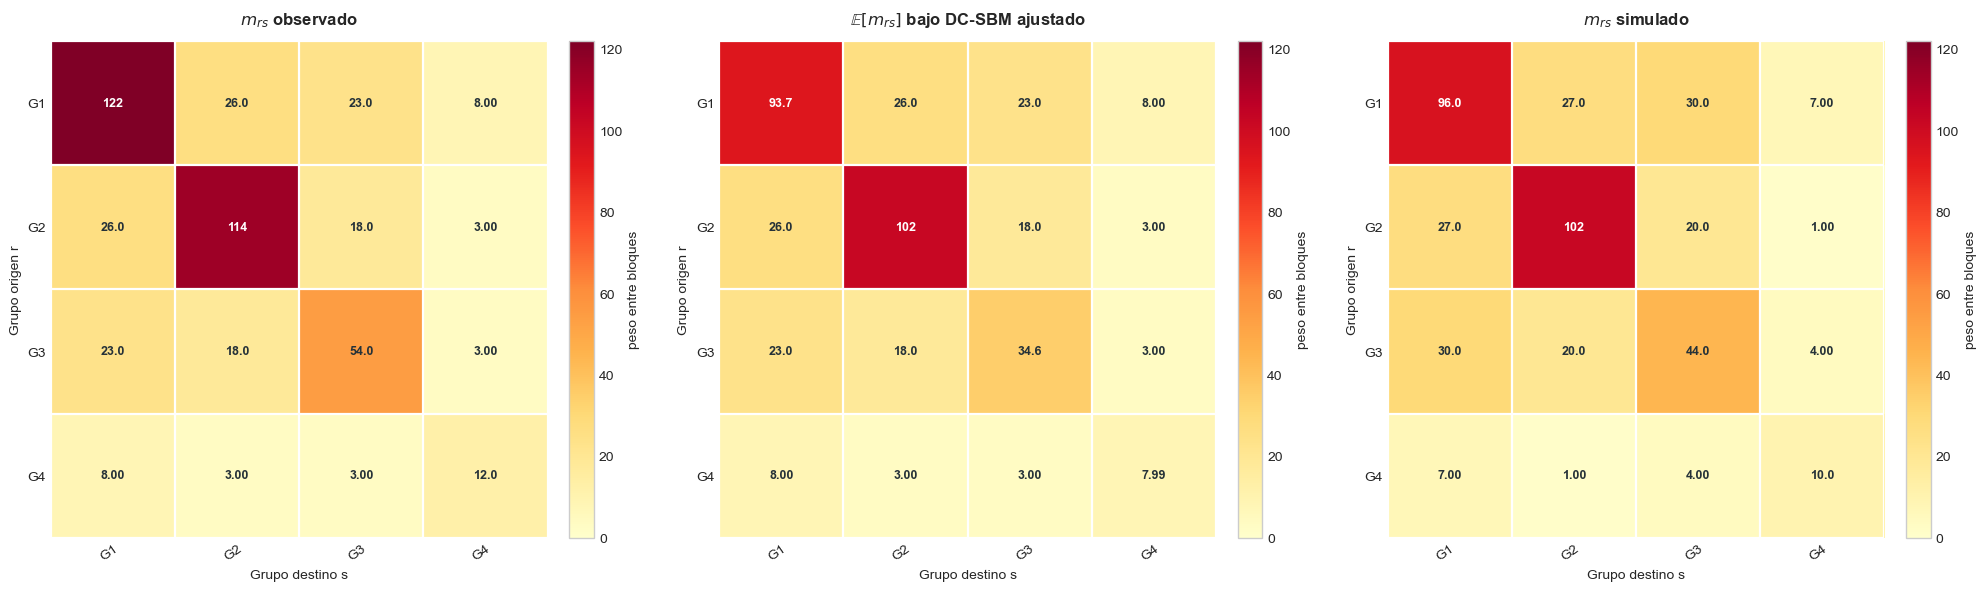

In [17]:

# Visualización de matrices de bloque: observado, esperado y simulado.
observed_m_rs = fitted_stats["m_rs"]
expected_m_rs = expected_m_rs_no_loops(fitted_stats)
simulated_m_rs = aggregate_m_rs_under_fixed_partition(G_dcsbm_sim_sw, fitted_stats, weight="weight")

matrices_to_plot = [
    (observed_m_rs, r"$m_{rs}$ observado"),
    (expected_m_rs, r"$\mathbb{E}[m_{rs}]$ bajo DC-SBM ajustado"),
    (simulated_m_rs, r"$m_{rs}$ simulado"),
]

group_names = fitted_stats["group_names"]
shared_norm = Normalize(*_matrix_color_limits([matrix for matrix, _ in matrices_to_plot]))
fig, axes = plt.subplots(1, 3, figsize=(20, 5.8), constrained_layout=True)

for ax, (matrix, title) in zip(axes, matrices_to_plot):
    _annotated_heatmap(
        ax,
        matrix,
        group_names,
        title,
        cmap="YlOrRd",
        norm=shared_norm,
        cbar_label="peso entre bloques",
    )

plt.show()


<!-- interpretacion-codex: matrices-simulacion -->
### Interpretación de observado, esperado y simulado por bloques

En estas matrices, **peso entre bloques** significa:

$$
m_{rs}
=
\sum_{i,j} \delta_{g_i r}\delta_{g_j s}A_{ij}.
$$

Como la red es no dirigida, los bloques internos cuentan doble en la matriz dirigida: una coaparición dentro de $G_r$ aporta a las dos direcciones. Por eso $m_{rr}$ no debe leerse como “número simple de aristas”, sino como peso dirigido interno.

La lectura específica es:

- **G1-G1** observado es $122$, pero el modelo espera cerca de $93.70$ sin lazos y la simulación da $96$. El arco ANAKIN-PADMÉ-Tatooine/Naboo está más cerrado en la película real que en el promedio del modelo.
- **G2-G2** observado es $114$, esperado $102.32$ y simulado $102$. El bloque Senado-Jedi-política se reproduce bastante bien, aunque la red real sigue siendo un poco más intensa.
- **G3-G3** observado es $54$, esperado $34.60$ y simulado $44$. La investigación de OBI-WAN/Kamino/Jango tiene más cohesión observada de la que el modelo espera solo por grados e intensidades de bloque.
- **G4-G4** observado es $12$, esperado $7.99$ y simulado $10$. El núcleo separatista pequeño también sale más cerrado en la película real.

En conjunto, los cuatro diagonales observados superan sus esperados. Esto es una señal fuerte de asortatividad narrativa: las subtramas de la película concentran más coapariciones internas que una red generada únicamente por el DC-SBM ajustado.

Nodos con mayor grado observado


,personaje,grupo,k_i_observado,k_i_simulado,diferencia
29,PADMÉ,G1,63.0,50.0,-13.0
26,OBI-WAN,G3,57.0,47.0,-10.0
1,ANAKIN,G1,56.0,53.0,-3.0
45,YODA,G2,27.0,34.0,7.0
23,MACE WINDU,G2,25.0,21.0,-4.0
30,PALPATINE,G2,18.0,12.0,-6.0
17,JAR JAR,G2,17.0,20.0,3.0
8,COUNT DOOKU,G2,13.0,10.0,-3.0
24,MAS AMEDDA,G2,13.0,13.0,0.0
36,SENATOR ASK AAK,G2,11.0,11.0,0.0


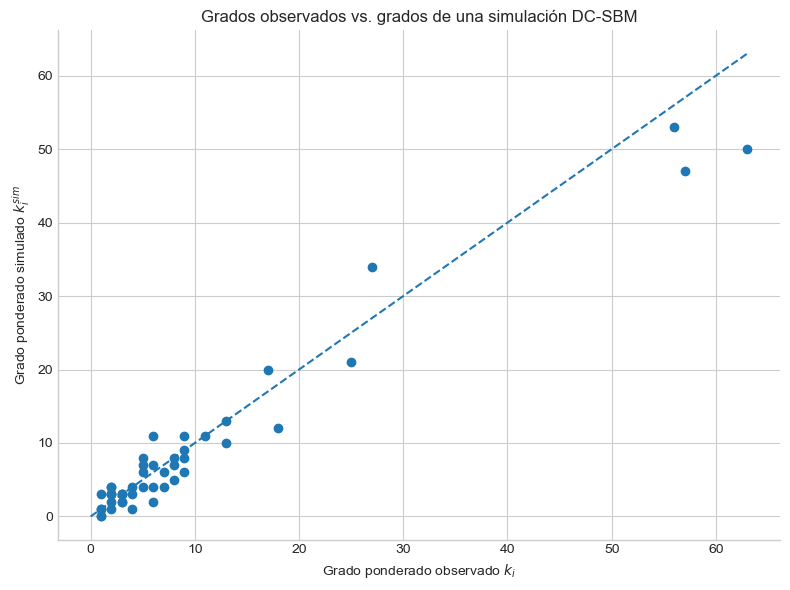

In [18]:

# Comparación de grados ponderados observados contra grados ponderados simulados.
degree_comparison_sw = pd.DataFrame(
    {
        "personaje": [labels_sw[node] for node in fitted_stats["nodes"]],
        "grupo": [f"G{fitted_stats['lookup'][node]+1}" for node in fitted_stats["nodes"]],
        "k_i_observado": [G_sw.degree(node, weight="weight") for node in fitted_stats["nodes"]],
        "k_i_simulado": [G_dcsbm_sim_sw.degree(node, weight="weight") for node in fitted_stats["nodes"]],
    }
)
degree_comparison_sw["diferencia"] = degree_comparison_sw["k_i_simulado"] - degree_comparison_sw["k_i_observado"]

print("Nodos con mayor grado observado")
display(degree_comparison_sw.sort_values("k_i_observado", ascending=False).head(15).round(4))

fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(degree_comparison_sw["k_i_observado"], degree_comparison_sw["k_i_simulado"])
max_degree = max(degree_comparison_sw["k_i_observado"].max(), degree_comparison_sw["k_i_simulado"].max())
ax.plot([0, max_degree], [0, max_degree], linestyle="--")
ax.set_xlabel(r"Grado ponderado observado $k_i$")
ax.set_ylabel(r"Grado ponderado simulado $k_i^{sim}$")
ax.set_title("Grados observados vs. grados de una simulación DC-SBM")
plt.tight_layout()
plt.show()


<!-- interpretacion-codex: grados -->
### Interpretación de los grados observados vs. simulados

La comparación de grados muestra qué tan bien la simulación reproduce la centralidad de cada personaje.

- PADMÉ baja de $63$ observado a $50$ simulado. El modelo reconoce que es central, pero subestima su papel como puente entre Senado, Naboo, Anakin y Geonosis.
- OBI-WAN baja de $57$ a $47$. También se subestima: su investigación conecta demasiadas escenas específicas para ser capturada completamente por una regla promedio de bloque.
- ANAKIN queda más cerca: $56$ observado contra $53$ simulado. Su peso está muy concentrado en el bloque PADMÉ/Tatooine, que el modelo sí reproduce mejor.
- YODA sube de $27$ a $34$ en la simulación. Esto puede pasar porque, al estar en un bloque institucional con varios nodos de grado medio-alto, el modelo reparte más peso esperado alrededor de él.

La diagonal punteada representa igualdad perfecta entre grado observado y simulado. Los puntos debajo de la diagonal son personajes subestimados por la simulación; los de arriba son sobreestimados. Los protagonistas narrativamente más específicos, sobre todo PADMÉ y OBI-WAN, aparecen subestimados.

Resumen Monte Carlo con 200 redes simuladas


,peso_total_no_dirigido,aristas_positivas,proporcion_interna,error_frobenius_vs_esperado,error_frobenius_vs_observado
mean,200.6200,128.6050,0.5959,24.3315,42.4009
std,14.5997,8.1104,0.0337,7.0625,11.0765
min,158.0000,106.0000,0.5082,9.2753,16.6733
max,241.0000,153.0000,0.7081,44.7081,70.6399


,simulacion,peso_total_no_dirigido,aristas_positivas,proporcion_interna,error_frobenius_vs_esperado,error_frobenius_vs_observado
0,1,183.0,112,0.5082,34.3976,67.9853
1,2,220.0,136,0.6091,19.9845,30.2985
2,3,196.0,131,0.6071,35.9995,58.4466
3,4,198.0,127,0.6465,15.6355,27.8927
4,5,208.0,131,0.6106,24.4227,38.9358


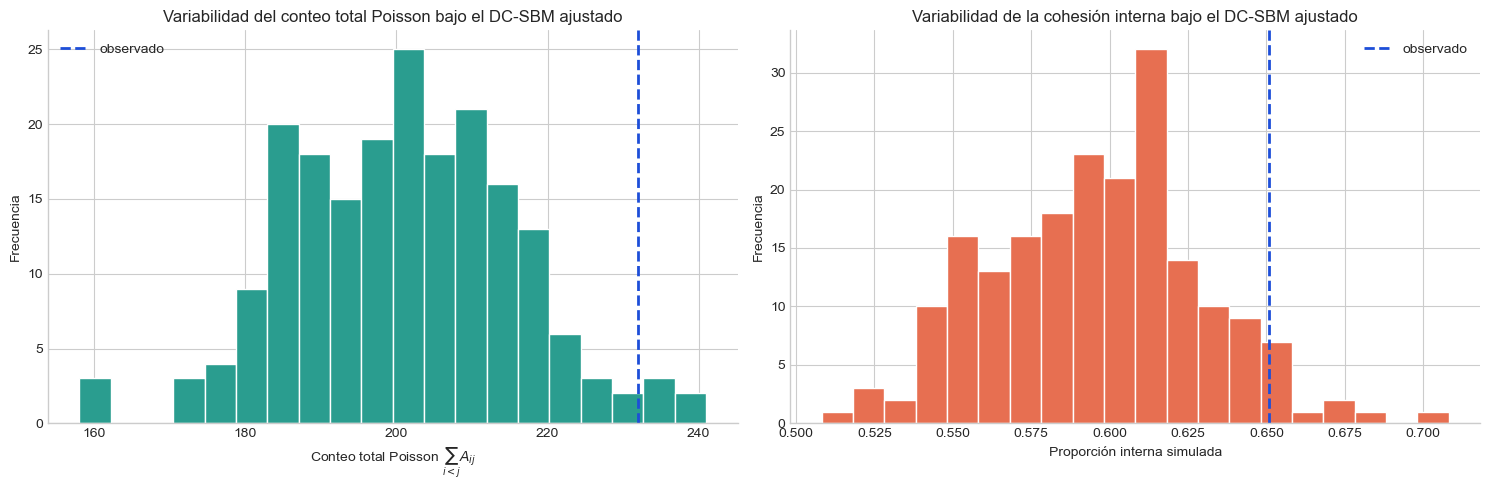

In [19]:

# Variabilidad Monte Carlo: muchas redes simuladas con los mismos parámetros ajustados.
def monte_carlo_dcsbm_summary(fitted_stats, n_simulations=200, seed=12345, weight="weight"):
    rng = np.random.default_rng(seed)
    rows = []
    observed_m_rs = fitted_stats["m_rs"]
    expected_m_rs = expected_m_rs_no_loops(fitted_stats)

    for simulation_id in range(n_simulations):
        sim_seed = int(rng.integers(0, 2**32 - 1))
        G_sim, _ = simulate_dcsbm_graph(fitted_stats, seed=sim_seed, weight=weight)
        sim_m_rs = aggregate_m_rs_under_fixed_partition(G_sim, fitted_stats, weight=weight)

        total_directed = sim_m_rs.sum()
        internal_share = np.trace(sim_m_rs) / total_directed if total_directed > 0 else np.nan
        frobenius_error_vs_expected = np.linalg.norm(sim_m_rs - expected_m_rs)
        frobenius_error_vs_observed = np.linalg.norm(sim_m_rs - observed_m_rs)

        rows.append(
            {
                "simulacion": simulation_id + 1,
                "peso_total_no_dirigido": G_sim.size(weight=weight),
                "aristas_positivas": G_sim.number_of_edges(),
                "proporcion_interna": internal_share,
                "error_frobenius_vs_esperado": frobenius_error_vs_expected,
                "error_frobenius_vs_observado": frobenius_error_vs_observed,
            }
        )

    return pd.DataFrame(rows)


mc_dcsbm_sw = monte_carlo_dcsbm_summary(fitted_stats, n_simulations=200, seed=2026, weight="weight")

mc_summary_sw = mc_dcsbm_sw.drop(columns=["simulacion"]).agg(["mean", "std", "min", "max"])
print("Resumen Monte Carlo con 200 redes simuladas")
display(mc_summary_sw.round(4))

display(mc_dcsbm_sw.head().round(4))

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

axes[0].hist(mc_dcsbm_sw["peso_total_no_dirigido"], bins=20, color="#2a9d8f", edgecolor="white")
axes[0].axvline(G_sw.size(weight="weight"), linestyle="--", color="#1d4ed8", linewidth=2, label="observado")
axes[0].set_xlabel(r"Conteo total Poisson $\sum_{i<j} A_{ij}$")
axes[0].set_ylabel("Frecuencia")
axes[0].set_title("Variabilidad del conteo total Poisson bajo el DC-SBM ajustado")
axes[0].legend()

axes[1].hist(mc_dcsbm_sw["proporcion_interna"], bins=20, color="#e76f51", edgecolor="white")
axes[1].axvline(fitted_stats["internal_share"], linestyle="--", color="#1d4ed8", linewidth=2, label="observado")
axes[1].set_xlabel("Proporción interna simulada")
axes[1].set_ylabel("Frecuencia")
axes[1].set_title("Variabilidad de la cohesión interna bajo el DC-SBM ajustado")
axes[1].legend()

plt.tight_layout()
plt.show()


<!-- interpretacion-codex: monte-carlo -->
### Interpretación Monte Carlo

En el histograma de peso total, **peso** significa:

$$
	ext{peso total no dirigido}
=
\sum_{i<j} A_{ij}^{\mathrm{sim}}.
$$

En palabras: es la suma de los conteos de aristas simuladas entre todos los pares de personajes.

Como usamos el modelo Poisson,

$$
A_{ij}^{\mathrm{sim}}
\sim
\operatorname{Poisson}(\lambda_{ij}),
$$

entonces $A_{ij}^{\mathrm{sim}}$ puede ser $0,1,2,3,\ldots$. Por eso se llama peso: si entre dos personajes sale $A_{ij}=3$, se interpreta como tres multiaristas o como una arista con peso $3$.

Si la red fuera estrictamente simple, donde solo hay $0$ o $1$, entonces

$$
\sum_{i<j} A_{ij}
=
	ext{número total de aristas}.
$$

En este caso:

$$
boxed{
	ext{peso total} \approx 	ext{número total de aristas, pero permitiendo conteos Poisson mayores que 1.}
}
$$

La línea punteada azul es el valor observado en la red real:

$$
\sum_{i<j} A_{ij}^{\mathrm{obs}}=232.
$$

El histograma muestra los valores de

$$
\sum_{i<j} A_{ij}^{\mathrm{sim}}
$$

para muchas redes generadas aleatoriamente desde el DC-SBM ajustado.

Interpretación específica: el modelo ajustado genera muchas redes con peso total alrededor de $190$-$211$, con media $200.62$ y percentil 95 cercano a $224.05$. La red observada está en $232$, por encima del rango central de las simulaciones. Eso sugiere que la película real es algo más densa que lo que el DC-SBM suele generar.

Mejor nombre para la gráfica:

$$
boxed{
	ext{Variabilidad del conteo total Poisson }\sum_{i<j}A_{ij}	ext{ bajo el DC-SBM ajustado}
}
$$

La segunda gráfica, de proporción interna, dice algo complementario: la red observada tiene proporción interna $0.6509$, mientras que las simulaciones promedian $0.596$. Esto significa que los bloques narrativos reales están más cohesionados que los bloques generados por el modelo. En la trama, eso se ve como arcos compactos: ANAKIN-PADMÉ, OBI-WAN-Kamino y separatistas.

## Lectura de la simulación

La red simulada conserva la lógica estadística del DC-SBM ajustado: los nodos con mayor $k_i$ tienden a recibir más peso y los pares de grupos con mayor $\hat\omega_{rs}$ tienden a concentrar más conexiones. Aun así, la red simulada no tiene que ser idéntica a la observada, porque cada peso se genera aleatoriamente mediante una variable Poisson.

La comparación relevante no es nodo por nodo exacto, sino de patrones agregados:

$$
A_{ij}^{\mathrm{sim}}\sim \operatorname{Poisson}(
\hat\omega_{g_i g_j}
rac{k_i k_j}{2m})
\quad\Longrightarrow\quad
\mathbb{E}[A_{ij}^{\mathrm{sim}}]
=
\hat\omega_{g_i g_j}
rac{k_i k_j}{2m}.
$$

En las 200 simulaciones Monte Carlo, el peso total no dirigido tiene media cercana a $200.62$, con intervalo aproximado 5%-95% de $178.95$ a $224.05$. La red observada tiene peso $232$, por encima de ese rango central. Esto sugiere que el DC-SBM ajustado tiende a generar redes algo menos densas que la película real.

La proporción interna simulada tiene media $0.596$, mientras que la observada es $0.6509$. Es decir, la película real concentra más peso dentro de sus bloques narrativos de lo que una red típica del modelo reproduce. Esto refuerza la lectura de asortatividad: los arcos de Padmé/Anakin, Obi-Wan/Kamino y separatistas no solo existen, sino que están más cerrados de lo que el promedio Poisson espera.

$$
	ext{DC-SBM ajustado}
\;\Rightarrow\;
\lambda_{ij}=\hat\omega_{g_i g_j}
rac{k_i k_j}{2m}
\;\Rightarrow\;
A_{ij}^{\mathrm{sim}}\sim\operatorname{Poisson}(\lambda_{ij})
$$